# Híbrido con variables de contenido (NCF + TMDB)

En este cuadernillo se construye un modelo híbrido: parte de la misma red NCF que en RNcol.ipynb, pero además de los embeddings de usuario y película, se añaden variables de contenido de TMDB y los géneros de la película como entrada adicional a la red.

Fuente: curso de PyTorch de Datacamp

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import random
import matplotlib.pyplot as plt

Se fijan las semillas aleatorias para que el entrenamiento sea reproducible.

## Carga y preparación de datos

In [2]:
random.seed(73)
np.random.seed(73)
torch.manual_seed(73)
torch.cuda.manual_seed_all(73) #si hay gpu

Se carga hybrid.parquet, que combina para cada valoración:
- MovieLens: userId, rating, movieId, year, genres, timestamp
- TMDB: id, budget, popularity, vote_average, vote_count, revenue, runtime

In [3]:
df = pd.read_parquet("../../data/03_model_ready/hybrid.parquet").sort_values('movieId')

In [4]:
columnas = df.columns
columnas

Index(['userId', 'movieId', 'timestamp', 'rating', 'genres', 'year',
       'popularity', 'vote_average', 'vote_count', 'runtime',
       '(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
       'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller',
       'War', 'Western'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 100505 entries, 94039 to 104
Data columns (total 30 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   userId              100505 non-null  int64         
 1   movieId             100505 non-null  int64         
 2   timestamp           100505 non-null  datetime64[ms]
 3   rating              100505 non-null  float64       
 4   genres              100505 non-null  object        
 5   year                100505 non-null  Int64         
 6   popularity          100505 non-null  float64       
 7   vote_average        100505 non-null  float64       
 8   vote_count          100505 non-null  int64         
 9   runtime             100505 non-null  int64         
 10  (no genres listed)  100505 non-null  int64         
 11  Action              100505 non-null  int64         
 12  Adventure           100505 non-null  int64         
 13  Animation           100505 non-null  int64  

Se elimina la columna genres de texto, ya que los géneros ya están codificados como columnas binarias (Action, Adventure, Comedy...).

In [6]:
df =  df.drop(columns=['genres'])

Se comprueba cuántas películas ha valorado cada usuario: todos tienen un mínimo de 20.

In [7]:
peliculasPorUsuario = (df.groupby('userId').size().reset_index(name='numPeliculas').sort_values('numPeliculas', ascending=True))
peliculasPorUsuario
# todos tienen minimo 20 peliculas valoradas

,userId,numPeliculas
594,595,20
52,53,20
568,569,20
575,576,20
319,320,20
...,...,...
273,274,1343
447,448,1861
473,474,2103
598,599,2448


## Transformaciones logarítmicas
Veamos si es necesario aplicar transformaciones logarítmicas a las variables numéricas de contenido, para corregir distribuciones muy asimétricas.

In [8]:
df[['popularity','vote_average', 'vote_count', 'runtime' , 'year']].describe()

,popularity,vote_average,vote_count,runtime,year
count,100505.000000,100505.000000,100505.000000,100505.000000,100505.0
mean,7.943277,7.039492,6266.566439,114.575225,1994.422556
std,11.065159,0.801777,7170.891775,24.045922,14.360523
min,0.003500,0.000000,0.000000,2.000000,1902.0
25%,2.595900,6.514000,1179.000000,98.000000,1990.0
50%,4.774000,7.100000,3506.000000,111.000000,1997.0
75%,8.893600,7.600000,8922.000000,127.000000,2003.0
max,134.778800,8.894000,39920.000000,583.000000,2018.0


Posibles variables a las que aplicar la transformación: popularity y vote_count. A year no se le aplica ninguna transformación.

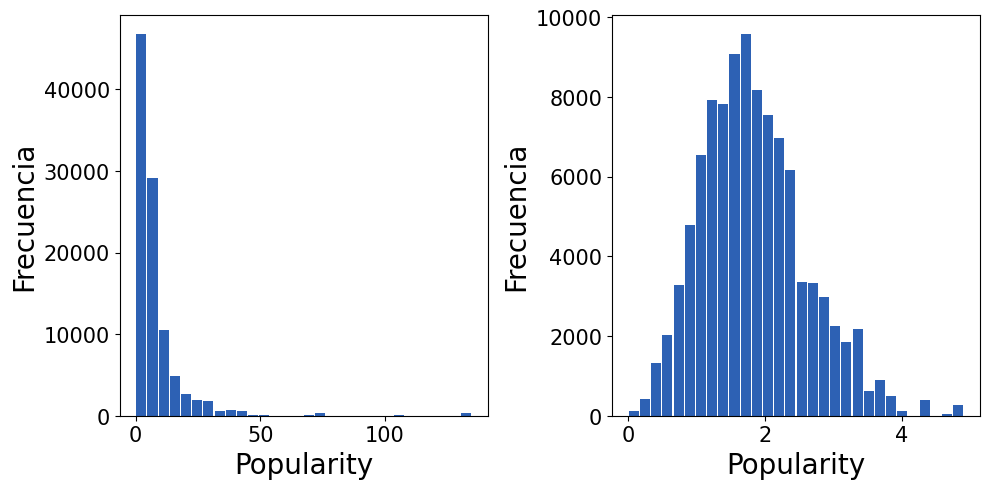

In [9]:
# popularity 
valores = df['popularity']
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# SIN  log
ax[0].hist(valores,bins=30, color="#2D61B4", rwidth =0.9, zorder= 2)
ax[0].set_xlabel('Popularity', fontsize=20)
ax[0].set_ylabel('Frecuencia', fontsize=20)
ax[0].tick_params(axis='x', labelsize=15)
ax[0].tick_params(axis='y', labelsize=15)
# log
ax[1].hist(np.log(valores+1),bins=30, color="#2D61B4", rwidth =0.9, zorder= 2)
ax[1].set_xlabel('Popularity', fontsize=20)
ax[1].set_ylabel('Frecuencia', fontsize=20)
ax[1].tick_params(axis='x', labelsize=15)
ax[1].tick_params(axis='y', labelsize=15)

plt.tight_layout()
plt.show()

distribución sesgada a la derecha. Al aplicar log se corrige la asimetría. Tiene sentido aplicar la transformación

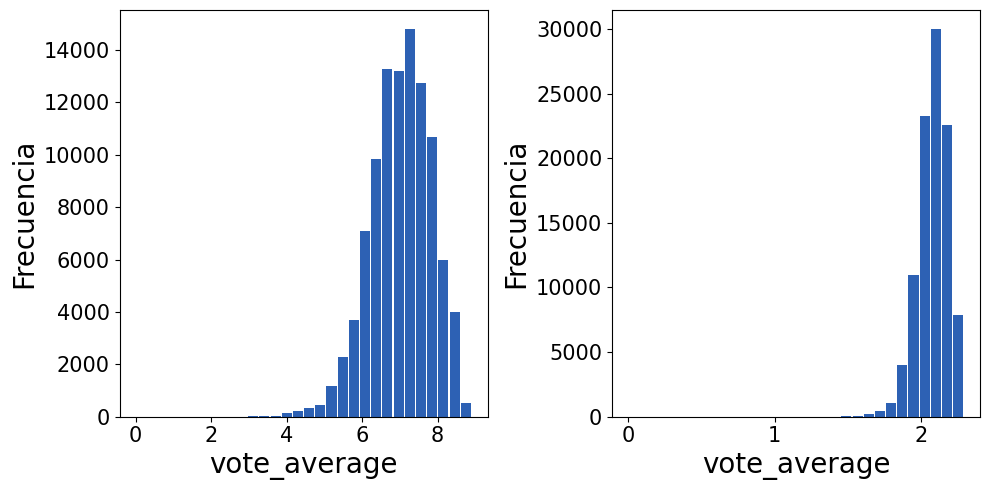

In [10]:
# vote_average
valores = df['vote_average']
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# SIN  log
ax[0].hist(valores,bins=30, color="#2D61B4", rwidth =0.9, zorder= 2)
ax[0].set_xlabel('vote_average', fontsize=20)
ax[0].set_ylabel('Frecuencia', fontsize=20)
ax[0].tick_params(axis='x', labelsize=15)
ax[0].tick_params(axis='y', labelsize=15)
# log
ax[1].hist(np.log(valores +1),bins=30, color="#2D61B4", rwidth =0.9, zorder= 2)
ax[1].set_xlabel('vote_average', fontsize=20)
ax[1].set_ylabel('Frecuencia', fontsize=20)
ax[1].tick_params(axis='x', labelsize=15)
ax[1].tick_params(axis='y', labelsize=15)

plt.tight_layout()
plt.show()

NO tiene sentido una transformación logarítmica en este caso. Distribución sesgada a la izquierda y datos acotados. 

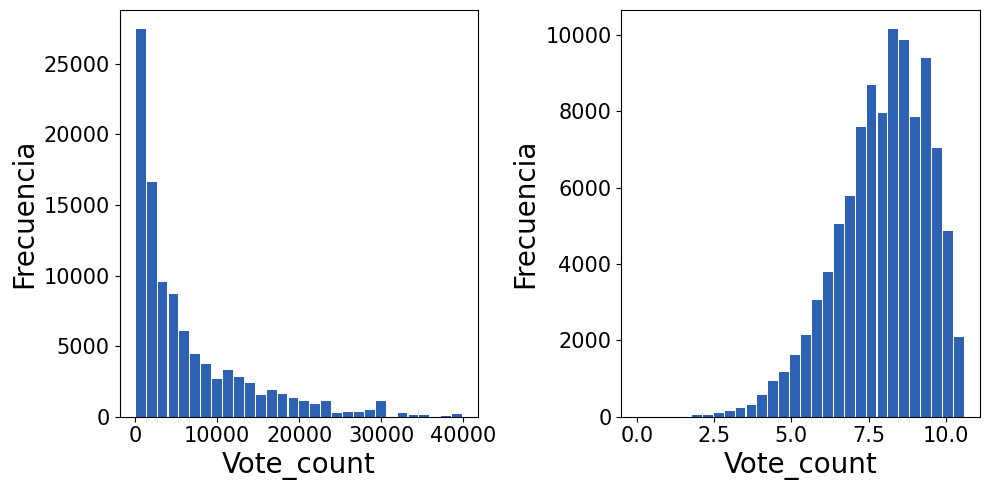

In [11]:
# vote_count
valores = df['vote_count']
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# SIN  log
ax[0].hist(valores,bins=30, color="#2D61B4", rwidth =0.9, zorder= 2)
ax[0].set_xlabel('Vote_count', fontsize=20)
ax[0].set_ylabel('Frecuencia', fontsize=20)
ax[0].tick_params(axis='x', labelsize=15)
ax[0].tick_params(axis='y', labelsize=15)
# log
ax[1].hist(np.log(valores +1),bins=30, color="#2D61B4", rwidth =0.9, zorder= 2)
ax[1].set_xlabel('Vote_count', fontsize=20)
ax[1].set_ylabel('Frecuencia', fontsize=20)
ax[1].tick_params(axis='x', labelsize=15)
ax[1].tick_params(axis='y', labelsize=15)

plt.tight_layout()
plt.show()

Sí tiene sentido la transformación

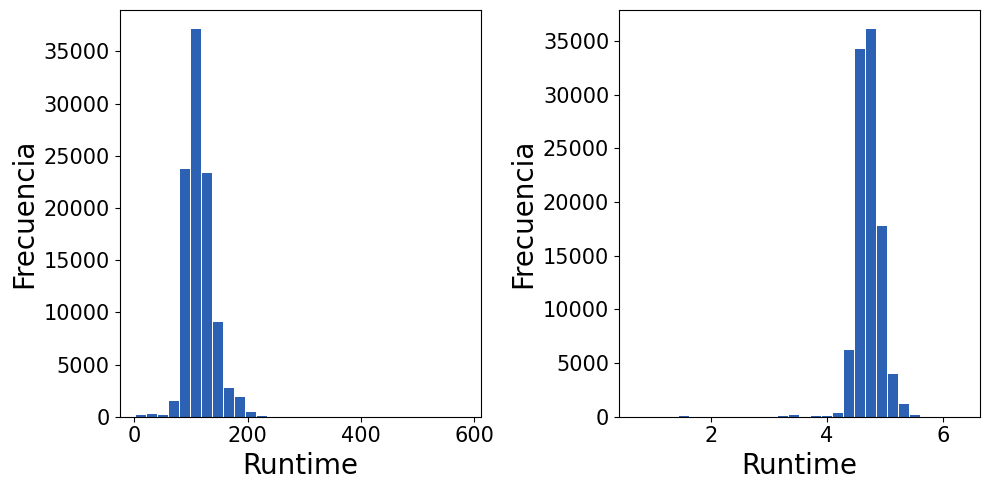

In [12]:
# runtime 
valores = df['runtime']
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# SIN  log
ax[0].hist(valores,bins=30, color="#2D61B4", rwidth =0.9, zorder= 2)
ax[0].set_xlabel('Runtime', fontsize=20)
ax[0].set_ylabel('Frecuencia', fontsize=20)
ax[0].tick_params(axis='x', labelsize=15)
ax[0].tick_params(axis='y', labelsize=15)
# log
ax[1].hist(np.log(valores),bins=30, color="#2D61B4", rwidth =0.9, zorder= 2)
ax[1].set_xlabel('Runtime', fontsize=20)
ax[1].set_ylabel('Frecuencia', fontsize=20)
ax[1].tick_params(axis='x', labelsize=15)
ax[1].tick_params(axis='y', labelsize=15)

plt.tight_layout()
plt.show()

No aporta nada la transformación.

Se aplica transformación a Popularity y vote_count.

In [13]:
df['popularity']= np.log(df['popularity']+1)
df['vote_count']= np.log(df['vote_count']+1)

## Partición en train, val y test
Partición preliminar por usuario y de forma temporal (70/15/15), igual que en el resto de modelos. Más adelante se repite este mismo proceso tras eliminar la columna timestamp, y esa segunda partición es la que se usa realmente en el resto del cuadernillo.

In [14]:
# PARTICIÓN TRAIN /VAL / TEST.
train = pd.DataFrame()
val   = pd.DataFrame()
test  = pd.DataFrame()

# dfUser = pd.read_parquet("../../../data/02_silver/ratingsFinal.parquet")
dfUser = df.sort_values(['userId', 'timestamp'])

def particion(ratingsUser):
    global train, val, test
    n       = len(ratingsUser)
    p_train = round(n * 0.70)
    p_val   = round(n * 0.85)

    trainPar = ratingsUser.head(p_train)
    valPar   = ratingsUser.iloc[p_train:p_val]
    testPar  = ratingsUser.tail(n - p_val)

    train = pd.concat([train, trainPar], ignore_index=True)
    val   = pd.concat([val,   valPar],   ignore_index=True)
    test  = pd.concat([test,  testPar],  ignore_index=True)

for i in dfUser['userId'].unique():
    particion(dfUser[dfUser['userId'] == i])

print(f"Train: {len(train)} ratings")
print(f"Val:   {len(val)} ratings")
print(f"Test:  {len(test)} ratings")

Train: 70342 ratings
Val:   15103 ratings
Test:  15060 ratings


Las variables numéricas se normalizan (media 0, desviación 1) para que todas tengan la misma escala: popularity, vote_average, vote_count, runtime y year. La media y la desviación se calculan sobre train y se aplican después a los tres conjuntos.

## Preparación para la red NCF

Fuente: https://www.geeksforgeeks.org/deep-learning/neural-collaborative-filtering/

Las capas de embedding de PyTorch necesitan índices consecutivos empezando en 0, y los IDs originales de usuarios y películas no lo son. Por eso se construye un diccionario que traduce cada userId y cada movieId a un índice consecutivo.

In [15]:
# índices consecutivos para usuarios
userIndice = {}
i = 0

for user in df["userId"].unique():
    userIndice[user] = i
    i += 1

In [16]:
# índices consecutivos para películas
movieIndice = {}
i = 0

for movie in df["movieId"].unique():
    movieIndice[movie] = i
    i += 1

In [17]:
df["userIndice"] = df["userId"].map(userIndice)
df["movieIndice"] = df["movieId"].map(movieIndice)

In [18]:
df.sort_values('userId')

,userId,movieId,timestamp,rating,year,popularity,vote_average,vote_count,runtime,(no genres listed),...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,userIndice,movieIndice
594,1,1793,2000-07-30 18:23:24,4.0,1997,0.545517,5.794,3.555348,106,0,...,0,0,0,0,0,0,0,0,15,1322
44422,1,2395,2000-07-30 18:18:13,5.0,1998,1.237388,7.395,7.912423,93,0,...,0,0,0,0,0,0,0,0,15,1792
90992,1,2028,2000-07-30 18:31:28,4.0,1998,2.939432,8.226,9.756031,169,0,...,0,0,0,0,0,0,1,0,15,1499
68255,1,500,2000-07-30 18:20:08,3.0,1993,1.892344,7.200,8.798304,125,0,...,0,0,0,0,0,0,0,0,15,436
40469,1,2991,2000-07-30 18:37:51,5.0,1973,1.510369,6.500,7.734996,121,0,...,0,0,0,0,0,1,0,0,15,2247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68157,610,104241,2016-11-19 08:38:29,3.0,2013,1.584387,6.405,8.792853,103,0,...,0,0,0,0,0,0,0,0,149,8141
75911,610,608,2016-11-19 08:08:53,4.5,1996,2.032848,7.849,9.116030,98,0,...,0,0,0,0,0,1,0,0,149,520
56581,610,104243,2017-05-03 21:10:45,3.5,2013,1.871494,6.300,8.392537,119,0,...,1,0,0,0,1,1,0,0,149,8142
55896,610,103810,2017-05-03 21:41:23,3.0,2013,1.785070,6.500,8.371705,116,0,...,0,0,0,0,0,1,0,0,149,8126


Se repite la partición en train, val y test, esta vez sobre df ya con los índices de usuario/película añadidos y sin la columna timestamp (no se necesita como variable del modelo). Esta es la partición que se usa en el resto del cuadernillo.

In [19]:
# PARTICIÓN TRAIN /VAL / TEST.
train = pd.DataFrame()
val   = pd.DataFrame()
test  = pd.DataFrame()

# dfUser = pd.read_parquet("../../../data/02_silver/ratingsFinal.parquet")
dfUser = df.sort_values(['userId', 'timestamp'])
dfUser=dfUser.drop(columns=['timestamp'])
def particion(ratingsUser):
    global train, val, test
    n       = len(ratingsUser)
    p_train = round(n * 0.70)
    p_val   = round(n * 0.85)

    trainPar = ratingsUser.head(p_train)
    valPar   = ratingsUser.iloc[p_train:p_val]
    testPar  = ratingsUser.tail(n - p_val)

    train = pd.concat([train, trainPar], ignore_index=True)
    val   = pd.concat([val,   valPar],   ignore_index=True)
    test  = pd.concat([test,  testPar],  ignore_index=True)

for i in dfUser['userId'].unique():
    particion(dfUser[dfUser['userId'] == i])

print(f"Train: {len(train)} ratings")
print(f"Val:   {len(val)} ratings")
print(f"Test:  {len(test)} ratings")

Train: 70342 ratings
Val:   15103 ratings
Test:  15060 ratings


Se calculan media y desviación típica de las variables numéricas sobre train, y se usan para normalizar train, val y test.

In [20]:
columnasNorm = ['popularity','vote_average', 'vote_count', 'runtime' , 'year']
media = train[columnasNorm].mean()
std = train[columnasNorm].std()

In [21]:
train[columnasNorm] =  (train[columnasNorm]-media)/std
val[columnasNorm] =  (val[columnasNorm]-media)/std
test[columnasNorm] =  (test[columnasNorm]-media)/std

Se define la lista variables: las columnas de contenido (year, popularity, vote_average, vote_count, runtime y los géneros binarios) que se usarán como entrada adicional de la red, junto a los embeddings de usuario y película.

In [22]:
columnas = ['userId', 'movieId', 'rating', 'year', 'popularity',
       'vote_average', 'vote_count', 'runtime','(no genres listed)', 'Action', 'Adventure',
       'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama',
       'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery',
       'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', 'userIdice',
       'movieIndice']




#  variables predictoras del modelo
variables =  ['year', 'popularity',
       'vote_average', 'vote_count', 'runtime','(no genres listed)', 'Action', 'Adventure',
       'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama',
       'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery',
       'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


El rating se escala al intervalo [0, 1], ya que la red termina con una sigmoide, cuya salida está en ese rango.

In [23]:
train['rating_norm'] = train['rating'] / 5.0
val['rating_norm']   = val['rating'] / 5.0
test['rating_norm']  = test['rating'] / 5.0

Número total de usuarios y de películas, necesario para definir el tamaño de las capas de embedding.

In [24]:
numUsers = df['userIndice'].max() + 1
numItems = df['movieIndice'].max() + 1

## Modelo híbrido con variables de TMDB
Se define un Dataset de PyTorch que, para cada valoración, devuelve el índice del usuario, el índice de la película, el vector de variables de contenido (X) y el rating normalizado. A diferencia de RNcol.ipynb, aquí cada ejemplo lleva también las variables de contenido.

In [25]:
class RedesDataSet(Dataset):
    def __init__(self,df):
        super().__init__()
        self.userInd = torch.tensor(df['userIndice'].values, dtype=torch.long)
        self.movieInd = torch.tensor(df['movieIndice'].values, dtype=torch.long)
        self.X = torch.from_numpy(df[variables].values.astype(np.float32))
        self.y = torch.from_numpy(df['rating_norm'].values.astype(np.float32))
       
    def __getitem__(self, ind):
        return self.userInd[ind], self.movieInd[ind],self.X[ind], self.y[ind]  
   
    def __len__(self):
        return self.y.shape[0]

Se crean los datasets y dataloaders de train, val y test. Además, dataset_train_val (y su dataloader) combina train y val, y se usará más adelante para reentrenar el modelo final con toda la información disponible antes de evaluar sobre test.

In [26]:
dataset_train = RedesDataSet(train)
dataset_val  = RedesDataSet(val)
dataset_test  = RedesDataSet(test)
dataset_train_val = RedesDataSet(pd.concat([train, val]))
dataloader_train= DataLoader(dataset_train, batch_size=200, shuffle=True)
dataloader_val   = DataLoader(dataset_val,   batch_size=200, shuffle=False)
dataloader_test  = DataLoader(dataset_test,  batch_size=200, shuffle=False)
dataloader_train_val = DataLoader(dataset_train_val, batch_size=200, shuffle=True)

La arquitectura es la misma que en RNcol.ipynb, pero antes de la primera capa totalmente conectada se concatenan también las numVar variables de contenido (X_feat), junto a los embeddings de usuario y película.

In [27]:
class NCF(nn.Module):
    def __init__(self, numUsers,numItems,numVar,dropout,embedDim):
        super(NCF, self).__init__()
        self.user_embedding = nn.Embedding(numUsers, embedDim)
        self.item_embedding = nn.Embedding(numItems, embedDim)
        self.fc1 = nn.Linear(embedDim*2+numVar, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, user, item, X_feat):
        user_emb = self.user_embedding(user)
        item_emb = self.item_embedding(item)
        x = torch.cat([user_emb, item_emb, X_feat], dim=-1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc3(x))
        return x.squeeze()

In [28]:
numVar=len(variables)

In [29]:
import copy

## Entrenamiento
La función entrenaRed entrena el modelo con el optimizador Adam y early stopping: en cada época se calcula la pérdida (MSE) en train y en val, y se guarda una copia del mejor modelo según la pérdida de validación. Si la validación no mejora durante early_stop épocas seguidas, se detiene el entrenamiento. Además, se guarda la evolución de la pérdida en train y val para poder graficarla después.

In [30]:
def  entrenaRed(lr,wd,dropout,epoca, early_stop,tam_embedd):
    criterion = nn.MSELoss()
    model =NCF(numUsers,numItems,numVar,dropout,tam_embedd)
    optimizer =optim.Adam(model.parameters(), lr=lr,weight_decay=wd)

    best_val = float('inf')
    best_model = None


    #  gráfico
    train_graf = []
    val_graf = []

    # parada
    stop = 0
    print(f"Entrenamiento con parámetros: lr={lr}, wd={wd}, drop={dropout}, época={epoca}, early_stop={early_stop}, dim_embed={tam_embedd}")
    for epoch in range(epoca):
        model.train()
        train_loss = 0
        for user, item,X, y in dataloader_train:
            optimizer.zero_grad()
            pred= model(user, item,X)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(dataloader_train)
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for user, item,X, y in dataloader_val:
                pred =model(user, item,X)
                loss= criterion(pred, y)
                val_loss += loss.item()
        val_loss /= len(dataloader_val)

        train_graf.append(train_loss)
        val_graf.append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_model = copy.deepcopy(model) #lo guarda en RAM
            stop = 0
        else:
            stop +=1 

        if (epoch + 1) %5 ==0:
            print(f"Epoch {epoch+1} |Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f}")
        epoca_parada=100    
        if stop >= early_stop:
            epoca_parada = epoch+1
            print(f"Early stopping en la época: {epoch+1}")
            break
        # print(f"Mejor RMSE en validación: {(best_val**0.5)*5:.4f}")
    return  best_model,best_val, train_graf,val_graf,epoca_parada


In [31]:
from matplotlib.ticker import MaxNLocator

graficaEntrenamiento convierte la pérdida (MSE en escala normalizada) a RMSE en la escala original del rating (multiplicando por 5), y dibuja su evolución por época para train y val. La gráfica se guarda como imagen en la carpeta graficoRNhybrid.

In [32]:
def graficaEntrenamiento(train_graf,val_graf, lr,wd, drop,n,tam_embedd):
    train_graf_RMSE = (np.array(train_graf)**0.5)*5
    val_graf_RMSE = (np.array(val_graf)**0.5)*5
    
    plt.figure()
    plt.plot(train_graf_RMSE,label="Entrenamiento",linewidth=5)
    plt.plot(val_graf_RMSE,label="Validación",linewidth=5)
    plt.xlabel('Épocas', fontsize=20)
    plt.ylabel('RMSE', fontsize=20)
    plt.xticks(fontsize=18)
  

    # ymax = int(np.ceil(max(np.max(train_graf_RMSE), np.max(val_graf_RMSE))))
    plt.yticks( fontsize=18)

    plt.legend()
    plt.title(f"lr = {lr}, wd = {wd}, dropout = {drop}\n" 
              f"dim. embeddings = {tam_embedd}", fontsize=15)
    plt.tight_layout()
    plt.savefig(f"graficoRNhybrid/{n}.png")
    plt.show()
    return f"{n}.png"


## Búsqueda de hiperparámetros
Se entrena el modelo para todas las combinaciones de dimensión de embedding (32, 64), learning rate, weight decay y dropout, guardando para cada una el mejor RMSE de validación y la gráfica de entrenamiento correspondiente.

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.027 | Val Loss: 0.030
Epoch 10 |Train Loss: 0.023 | Val Loss: 0.031
Epoch 15 |Train Loss: 0.019 | Val Loss: 0.033
Epoch 20 |Train Loss: 0.016 | Val Loss: 0.036
Early stopping en la época: 20


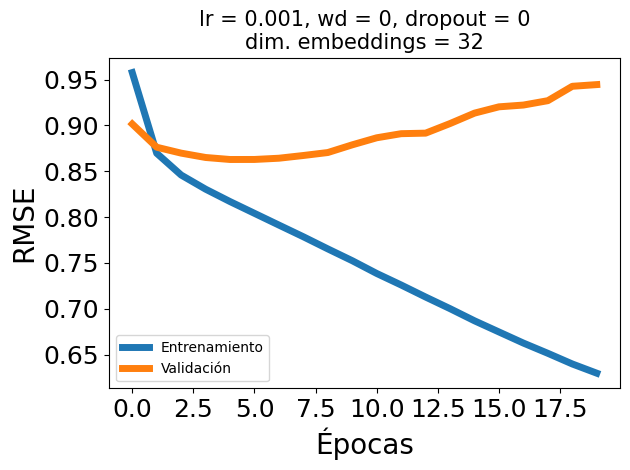

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.029 | Val Loss: 0.029
Epoch 10 |Train Loss: 0.026 | Val Loss: 0.029
Epoch 15 |Train Loss: 0.024 | Val Loss: 0.030
Epoch 20 |Train Loss: 0.023 | Val Loss: 0.030
Early stopping en la época: 24


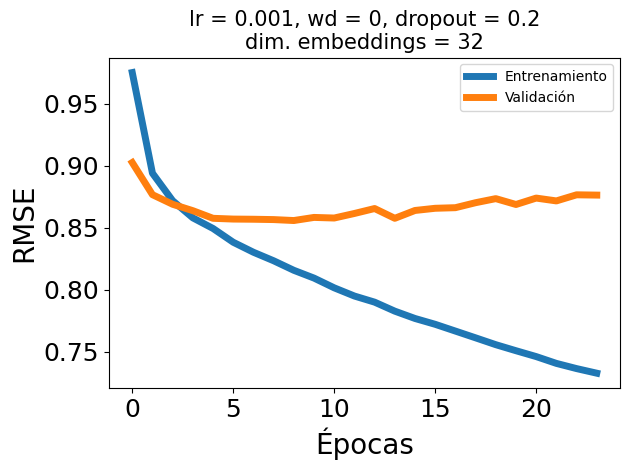

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.030 | Val Loss: 0.030
Epoch 10 |Train Loss: 0.028 | Val Loss: 0.029
Epoch 15 |Train Loss: 0.026 | Val Loss: 0.029
Epoch 20 |Train Loss: 0.025 | Val Loss: 0.030
Epoch 25 |Train Loss: 0.024 | Val Loss: 0.030
Early stopping en la época: 25


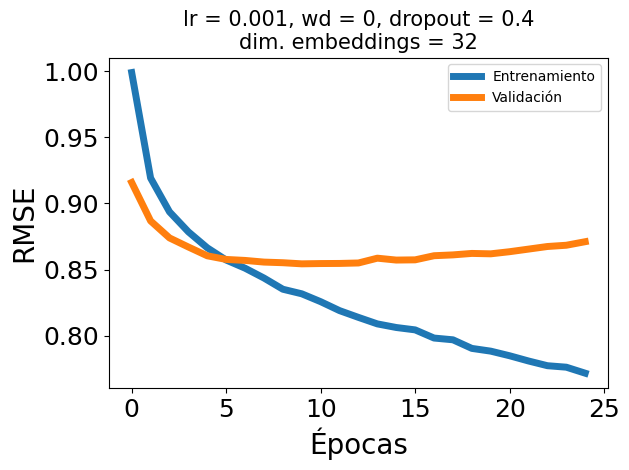

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.038 | Val Loss: 0.038
Epoch 10 |Train Loss: 0.038 | Val Loss: 0.039
Epoch 15 |Train Loss: 0.038 | Val Loss: 0.039
Early stopping en la época: 16


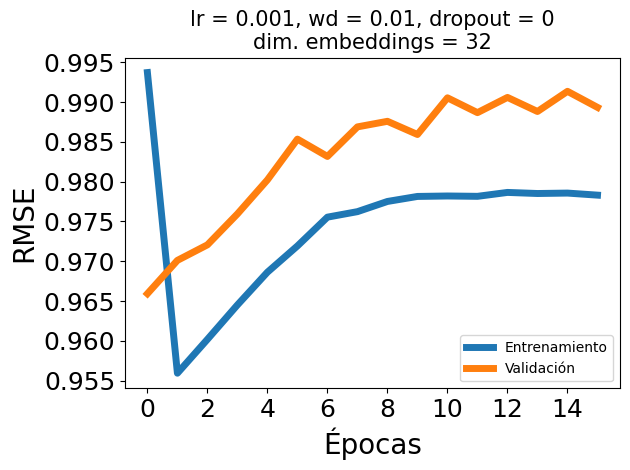

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.038 | Val Loss: 0.039
Epoch 10 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 15 |Train Loss: 0.039 | Val Loss: 0.039
Early stopping en la época: 16


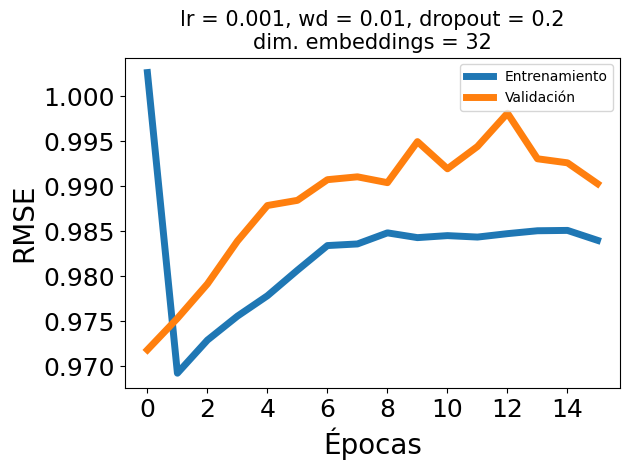

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.039 | Val Loss: 0.039
Epoch 10 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 15 |Train Loss: 0.039 | Val Loss: 0.040
Early stopping en la época: 17


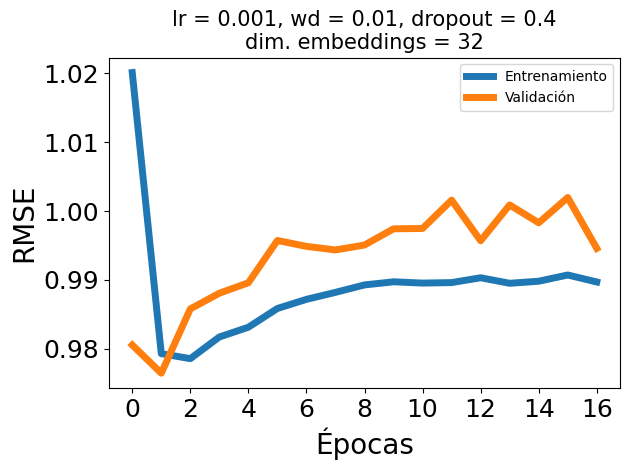

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.027 | Val Loss: 0.029
Epoch 10 |Train Loss: 0.022 | Val Loss: 0.029
Epoch 15 |Train Loss: 0.014 | Val Loss: 0.033
Epoch 20 |Train Loss: 0.010 | Val Loss: 0.035
Early stopping en la época: 24


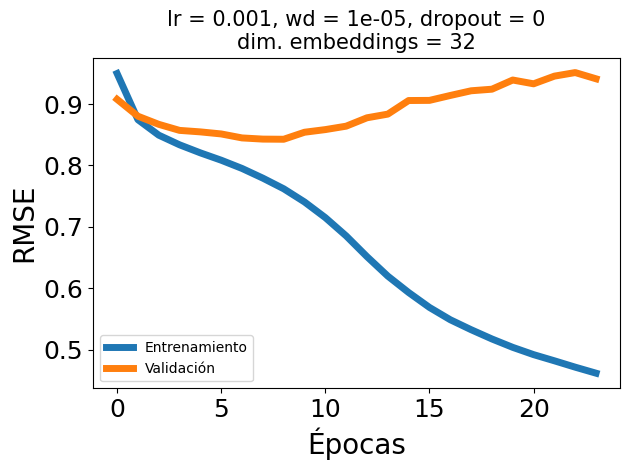

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.028 | Val Loss: 0.029
Epoch 10 |Train Loss: 0.025 | Val Loss: 0.028
Epoch 15 |Train Loss: 0.021 | Val Loss: 0.029
Epoch 20 |Train Loss: 0.017 | Val Loss: 0.031
Epoch 25 |Train Loss: 0.015 | Val Loss: 0.031
Early stopping en la época: 26


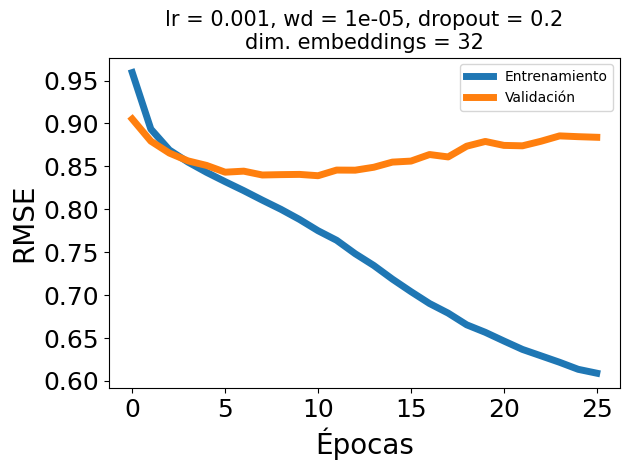

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.030 | Val Loss: 0.029
Epoch 10 |Train Loss: 0.027 | Val Loss: 0.028
Epoch 15 |Train Loss: 0.024 | Val Loss: 0.028
Epoch 20 |Train Loss: 0.022 | Val Loss: 0.029
Epoch 25 |Train Loss: 0.020 | Val Loss: 0.029
Early stopping en la época: 27


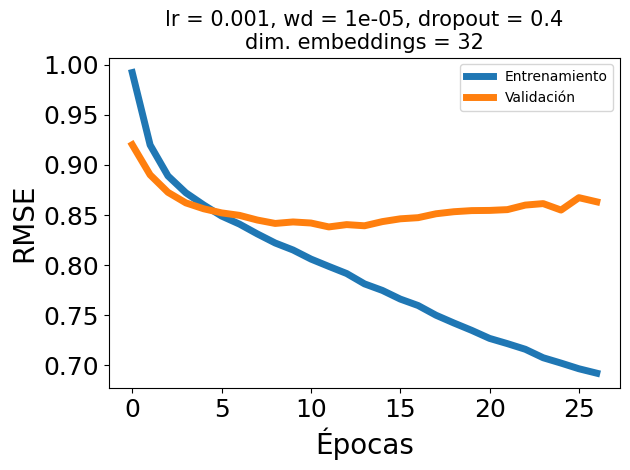

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.023 | Val Loss: 0.031
Epoch 10 |Train Loss: 0.015 | Val Loss: 0.036
Epoch 15 |Train Loss: 0.011 | Val Loss: 0.039
Early stopping en la época: 17


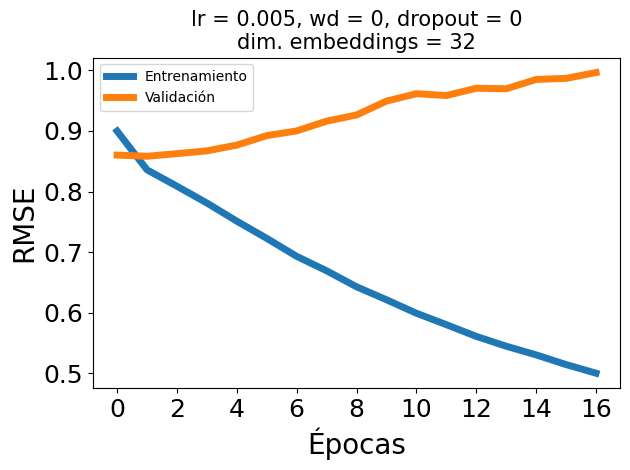

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.025 | Val Loss: 0.030
Epoch 10 |Train Loss: 0.021 | Val Loss: 0.032
Epoch 15 |Train Loss: 0.018 | Val Loss: 0.034
Early stopping en la época: 18


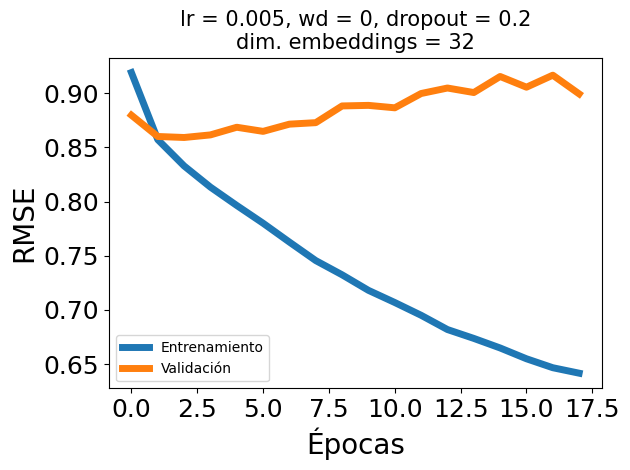

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.027 | Val Loss: 0.029
Epoch 10 |Train Loss: 0.024 | Val Loss: 0.031
Epoch 15 |Train Loss: 0.021 | Val Loss: 0.031
Epoch 20 |Train Loss: 0.020 | Val Loss: 0.032
Early stopping en la época: 20


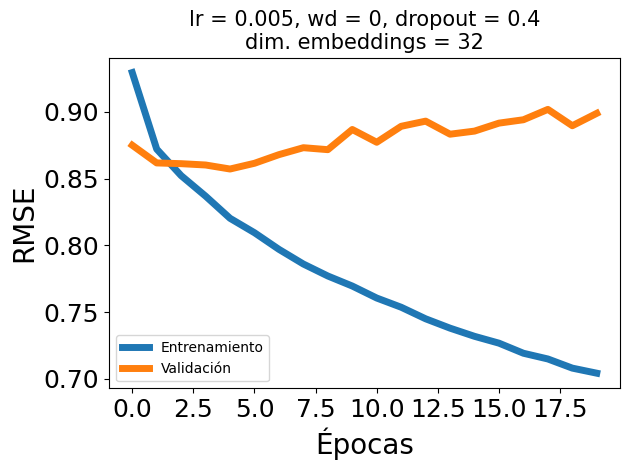

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.038 | Val Loss: 0.039
Epoch 10 |Train Loss: 0.038 | Val Loss: 0.039
Epoch 15 |Train Loss: 0.038 | Val Loss: 0.039
Epoch 20 |Train Loss: 0.038 | Val Loss: 0.039
Epoch 25 |Train Loss: 0.038 | Val Loss: 0.039
Early stopping en la época: 28


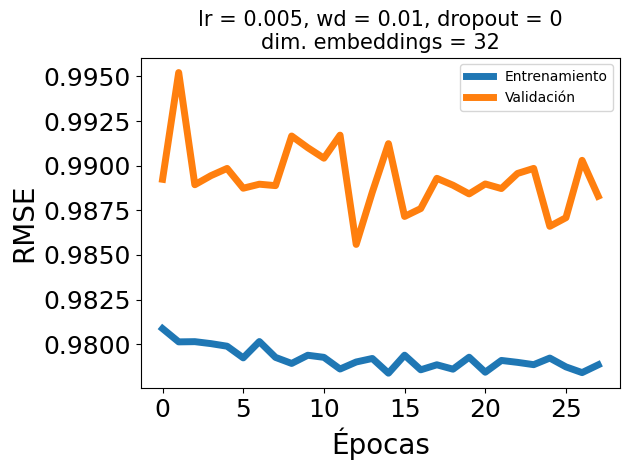

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.039 | Val Loss: 0.039
Epoch 10 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 15 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 20 |Train Loss: 0.039 | Val Loss: 0.040
Early stopping en la época: 21


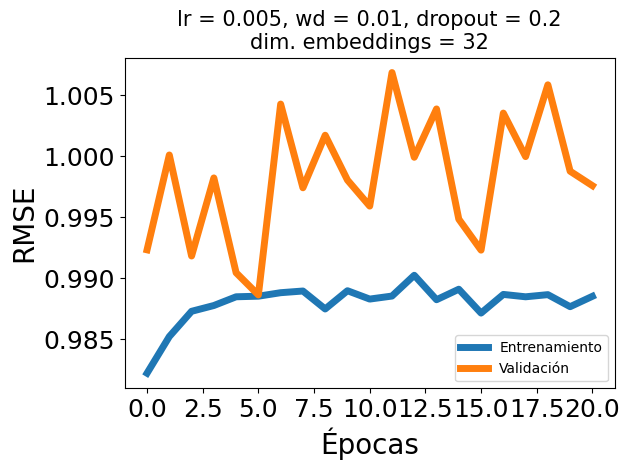

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.040 | Val Loss: 0.040
Epoch 10 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 15 |Train Loss: 0.040 | Val Loss: 0.040
Epoch 20 |Train Loss: 0.040 | Val Loss: 0.040
Epoch 25 |Train Loss: 0.040 | Val Loss: 0.040
Early stopping en la época: 29


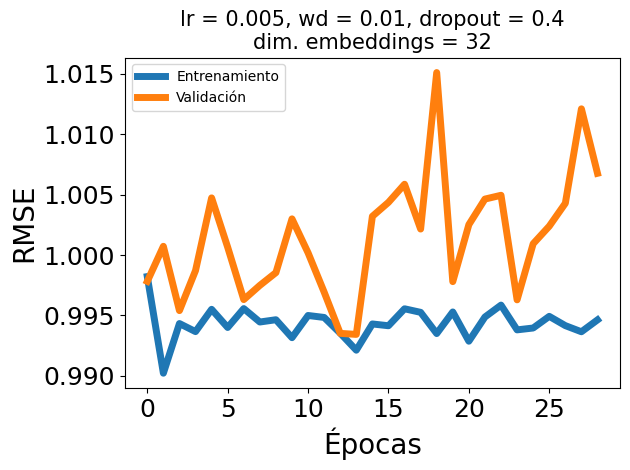

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.025 | Val Loss: 0.028
Epoch 10 |Train Loss: 0.022 | Val Loss: 0.028
Epoch 15 |Train Loss: 0.020 | Val Loss: 0.029
Epoch 20 |Train Loss: 0.019 | Val Loss: 0.030
Early stopping en la época: 21


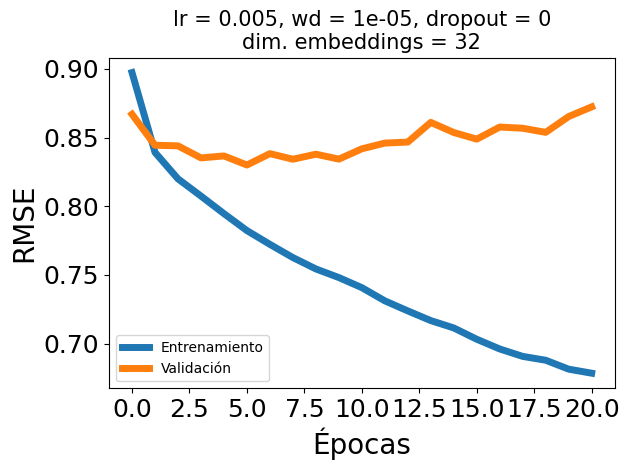

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.027 | Val Loss: 0.028
Epoch 10 |Train Loss: 0.025 | Val Loss: 0.028
Epoch 15 |Train Loss: 0.024 | Val Loss: 0.028
Epoch 20 |Train Loss: 0.023 | Val Loss: 0.029
Early stopping en la época: 21


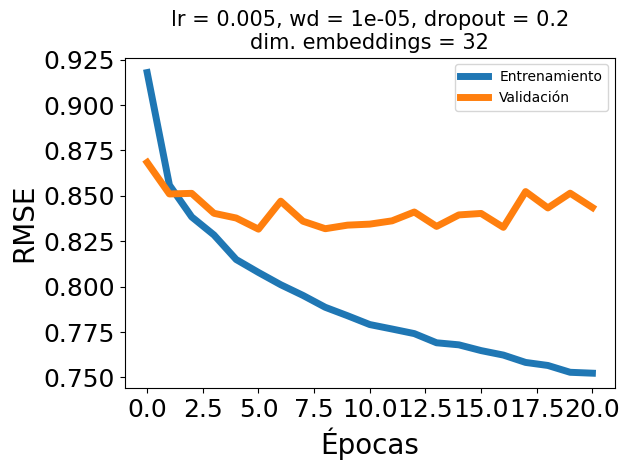

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.028 | Val Loss: 0.029
Epoch 10 |Train Loss: 0.027 | Val Loss: 0.029
Epoch 15 |Train Loss: 0.026 | Val Loss: 0.029
Epoch 20 |Train Loss: 0.025 | Val Loss: 0.028
Early stopping en la época: 24


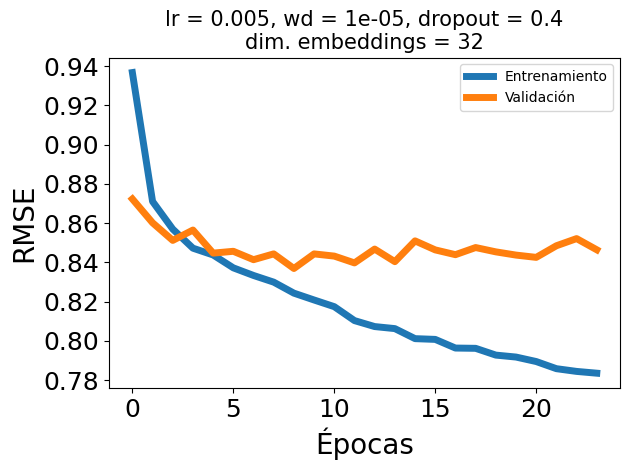

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.021 | Val Loss: 0.031
Epoch 10 |Train Loss: 0.013 | Val Loss: 0.036
Epoch 15 |Train Loss: 0.009 | Val Loss: 0.039
Early stopping en la época: 17


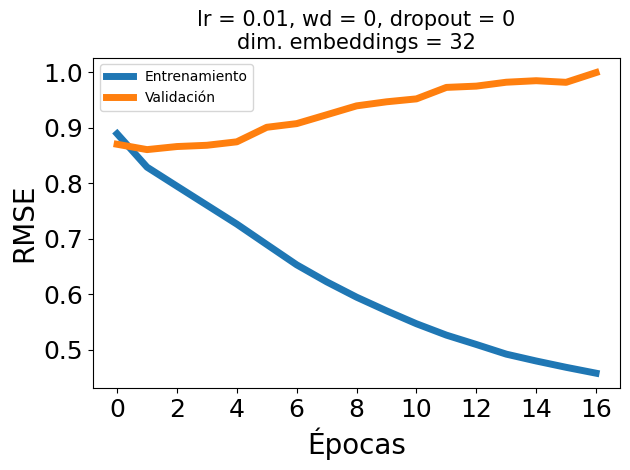

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.025 | Val Loss: 0.030
Epoch 10 |Train Loss: 0.020 | Val Loss: 0.033
Epoch 15 |Train Loss: 0.017 | Val Loss: 0.033
Early stopping en la época: 19


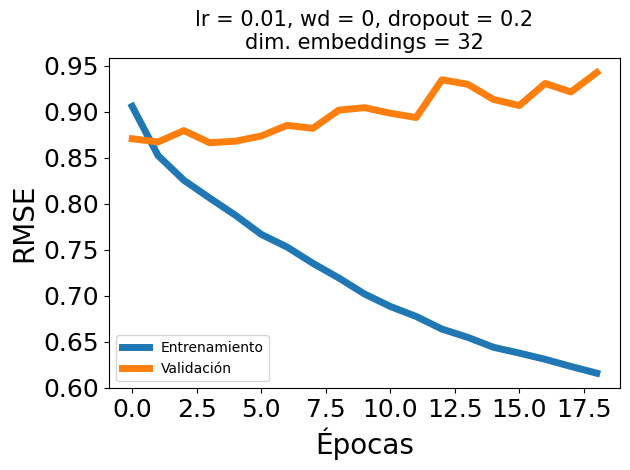

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.027 | Val Loss: 0.031
Epoch 10 |Train Loss: 0.024 | Val Loss: 0.031
Epoch 15 |Train Loss: 0.022 | Val Loss: 0.032
Early stopping en la época: 19


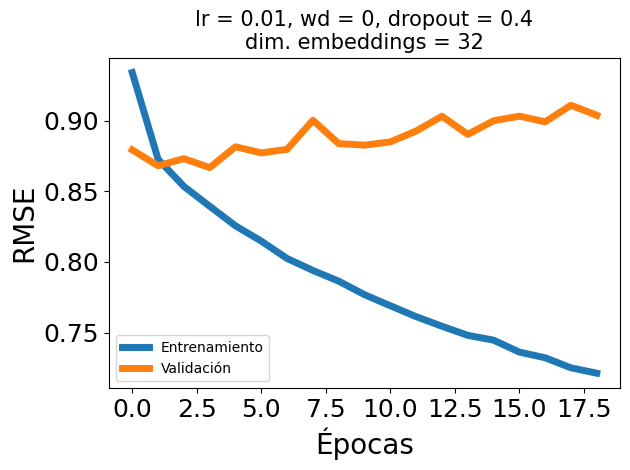

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.038 | Val Loss: 0.039
Epoch 10 |Train Loss: 0.038 | Val Loss: 0.040
Epoch 15 |Train Loss: 0.038 | Val Loss: 0.039
Early stopping en la época: 17


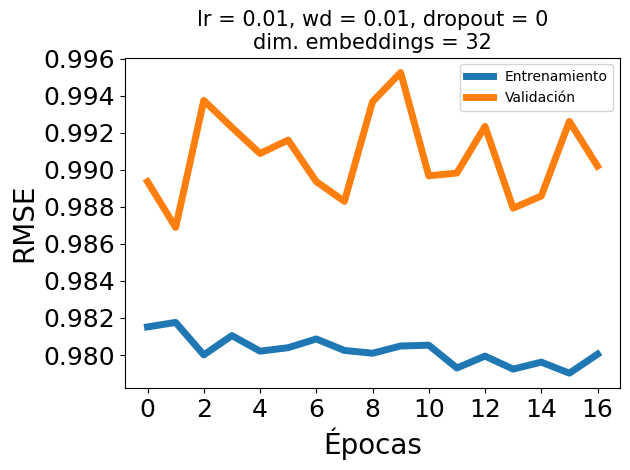

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 10 |Train Loss: 0.039 | Val Loss: 0.041
Epoch 15 |Train Loss: 0.039 | Val Loss: 0.039
Epoch 20 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 25 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 30 |Train Loss: 0.039 | Val Loss: 0.040
Early stopping en la época: 30


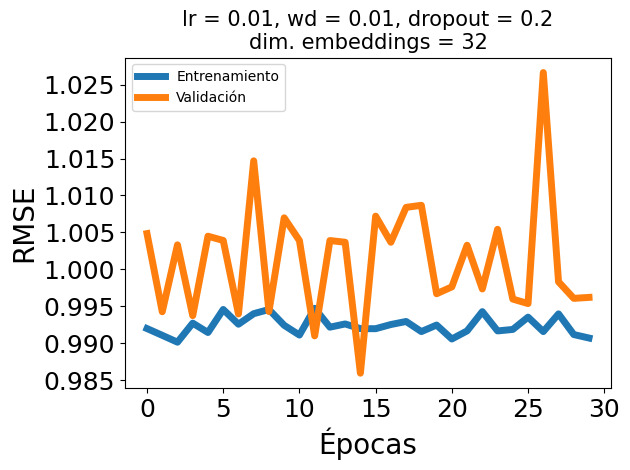

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.040 | Val Loss: 0.040
Epoch 10 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 15 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 20 |Train Loss: 0.040 | Val Loss: 0.040
Epoch 25 |Train Loss: 0.040 | Val Loss: 0.041
Early stopping en la época: 27


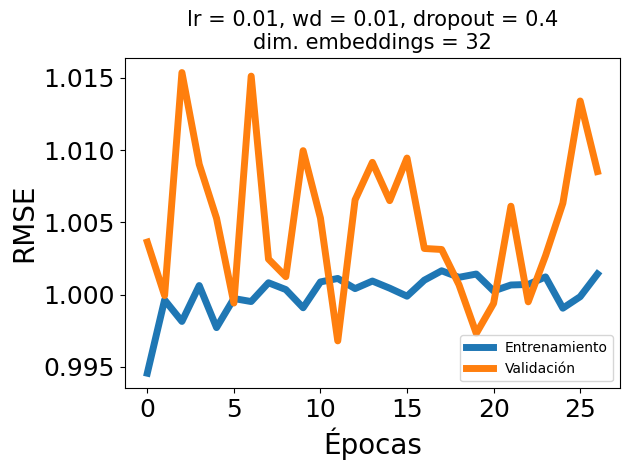

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.026 | Val Loss: 0.028
Epoch 10 |Train Loss: 0.025 | Val Loss: 0.028
Epoch 15 |Train Loss: 0.024 | Val Loss: 0.028
Epoch 20 |Train Loss: 0.024 | Val Loss: 0.028
Early stopping en la época: 22


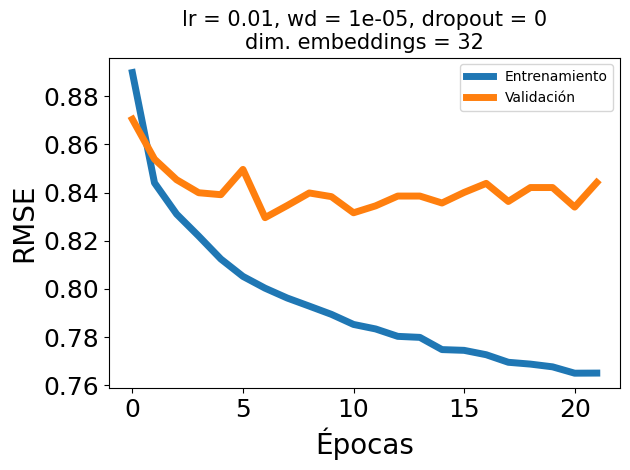

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.028 | Val Loss: 0.028
Epoch 10 |Train Loss: 0.027 | Val Loss: 0.029
Epoch 15 |Train Loss: 0.026 | Val Loss: 0.029
Epoch 20 |Train Loss: 0.026 | Val Loss: 0.028
Epoch 25 |Train Loss: 0.026 | Val Loss: 0.029
Epoch 30 |Train Loss: 0.026 | Val Loss: 0.028
Epoch 35 |Train Loss: 0.025 | Val Loss: 0.028
Early stopping en la época: 35


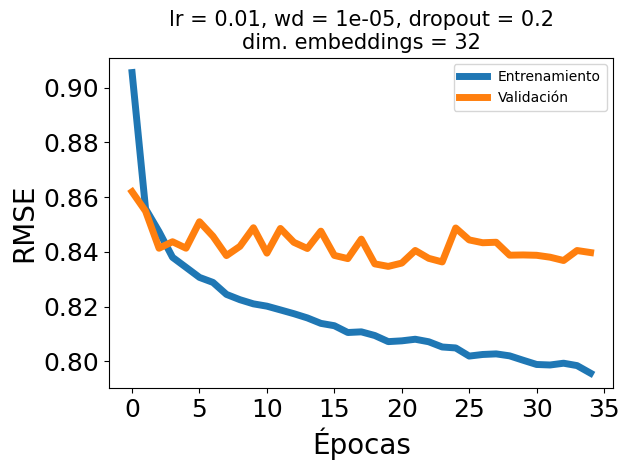

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.030 | Val Loss: 0.030
Epoch 10 |Train Loss: 0.029 | Val Loss: 0.029
Epoch 15 |Train Loss: 0.028 | Val Loss: 0.030
Epoch 20 |Train Loss: 0.028 | Val Loss: 0.029
Epoch 25 |Train Loss: 0.028 | Val Loss: 0.029
Epoch 30 |Train Loss: 0.028 | Val Loss: 0.029
Epoch 35 |Train Loss: 0.028 | Val Loss: 0.029
Early stopping en la época: 38


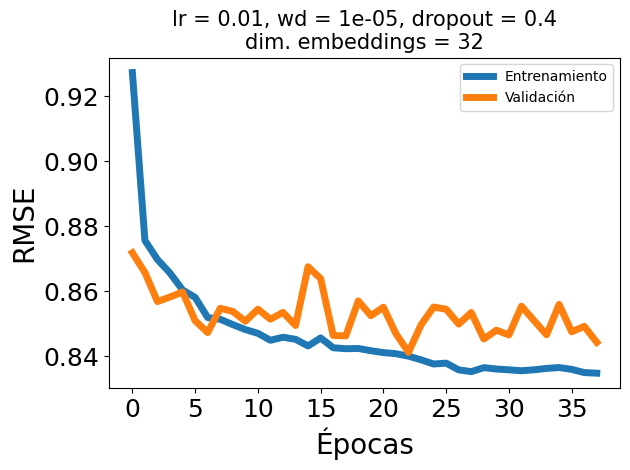

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.025 | Val Loss: 0.030
Epoch 10 |Train Loss: 0.020 | Val Loss: 0.034
Epoch 15 |Train Loss: 0.015 | Val Loss: 0.037
Early stopping en la época: 18


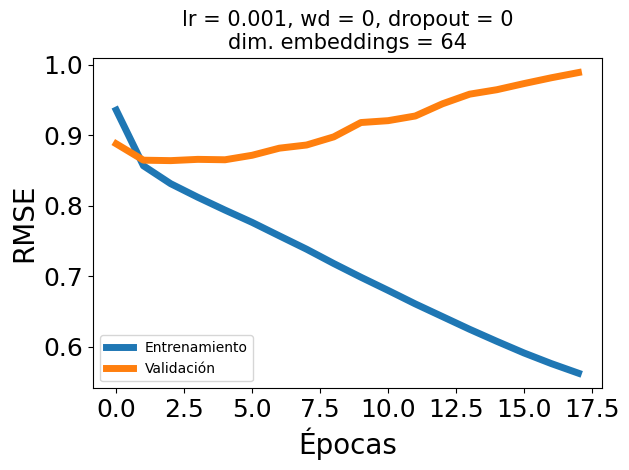

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.028 | Val Loss: 0.030
Epoch 10 |Train Loss: 0.024 | Val Loss: 0.030
Epoch 15 |Train Loss: 0.022 | Val Loss: 0.031
Epoch 20 |Train Loss: 0.020 | Val Loss: 0.032
Early stopping en la época: 23


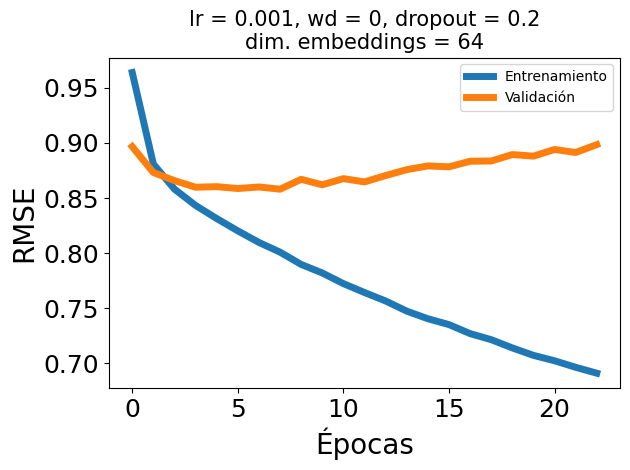

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.029 | Val Loss: 0.030
Epoch 10 |Train Loss: 0.026 | Val Loss: 0.030
Epoch 15 |Train Loss: 0.025 | Val Loss: 0.030
Epoch 20 |Train Loss: 0.023 | Val Loss: 0.030
Early stopping en la época: 24


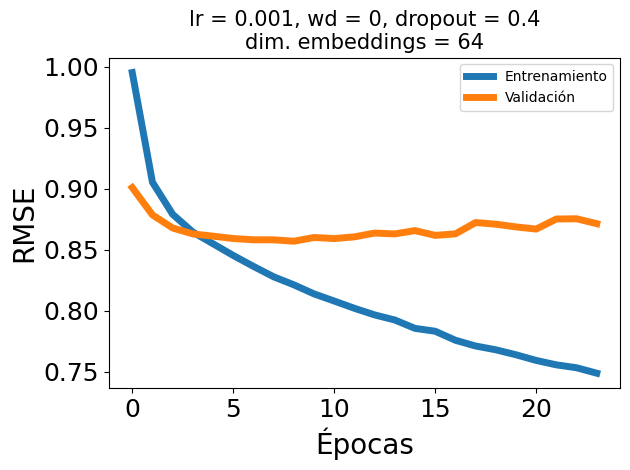

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.038 | Val Loss: 0.038
Epoch 10 |Train Loss: 0.038 | Val Loss: 0.039
Epoch 15 |Train Loss: 0.038 | Val Loss: 0.039
Early stopping en la época: 17


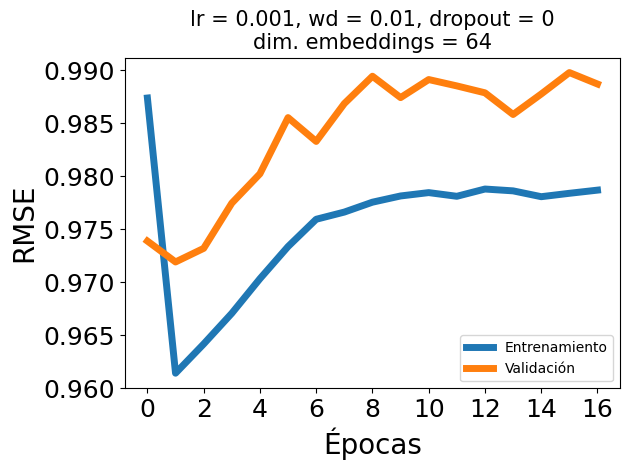

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.038 | Val Loss: 0.038
Epoch 10 |Train Loss: 0.039 | Val Loss: 0.039
Epoch 15 |Train Loss: 0.039 | Val Loss: 0.039
Early stopping en la época: 16


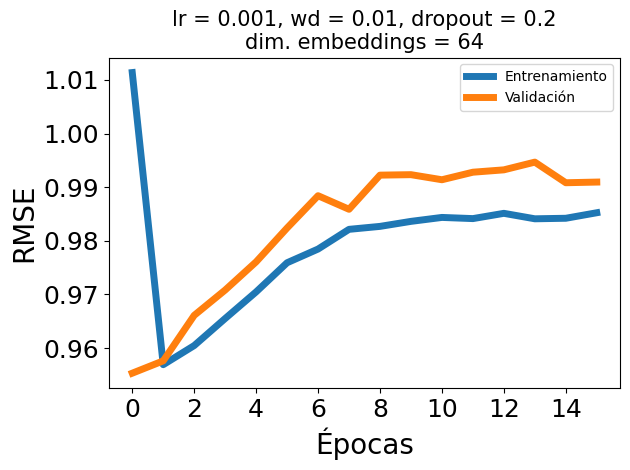

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.038 | Val Loss: 0.039
Epoch 10 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 15 |Train Loss: 0.039 | Val Loss: 0.040
Early stopping en la época: 16


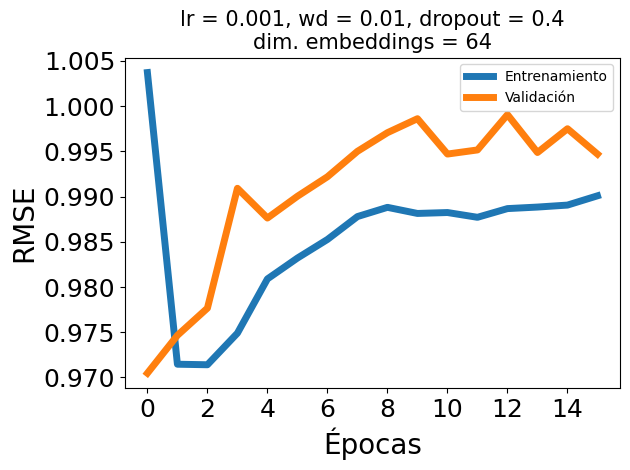

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.026 | Val Loss: 0.029
Epoch 10 |Train Loss: 0.020 | Val Loss: 0.029
Epoch 15 |Train Loss: 0.011 | Val Loss: 0.034
Epoch 20 |Train Loss: 0.008 | Val Loss: 0.035
Early stopping en la época: 22


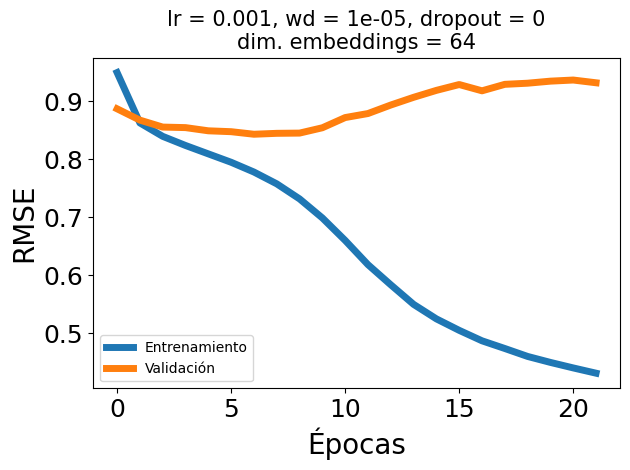

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.028 | Val Loss: 0.029
Epoch 10 |Train Loss: 0.024 | Val Loss: 0.028
Epoch 15 |Train Loss: 0.019 | Val Loss: 0.030
Epoch 20 |Train Loss: 0.016 | Val Loss: 0.030
Early stopping en la época: 24


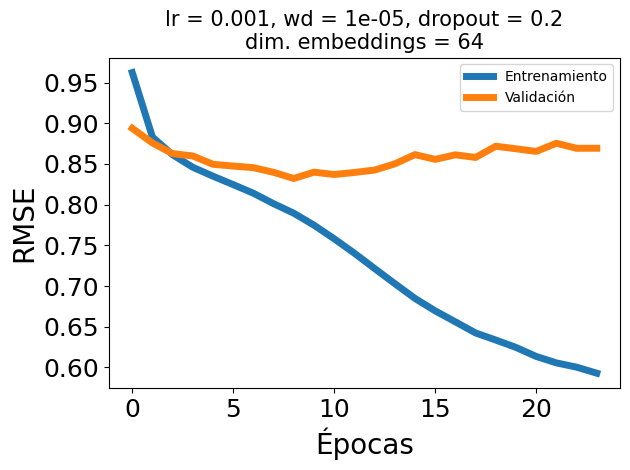

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.029 | Val Loss: 0.029
Epoch 10 |Train Loss: 0.026 | Val Loss: 0.028
Epoch 15 |Train Loss: 0.024 | Val Loss: 0.028
Epoch 20 |Train Loss: 0.021 | Val Loss: 0.029
Epoch 25 |Train Loss: 0.019 | Val Loss: 0.030
Early stopping en la época: 26


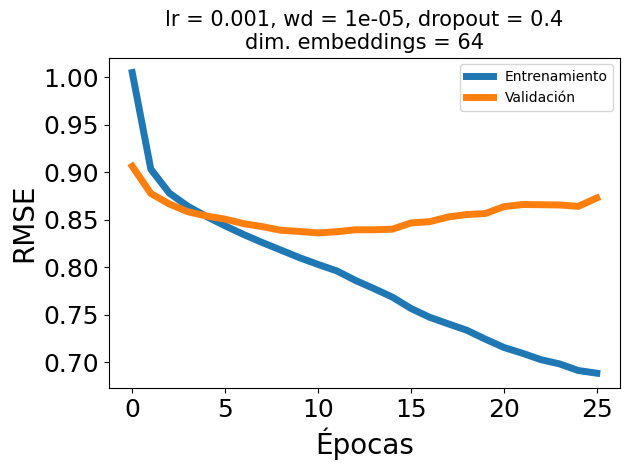

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.021 | Val Loss: 0.032
Epoch 10 |Train Loss: 0.013 | Val Loss: 0.036
Epoch 15 |Train Loss: 0.008 | Val Loss: 0.039
Early stopping en la época: 17


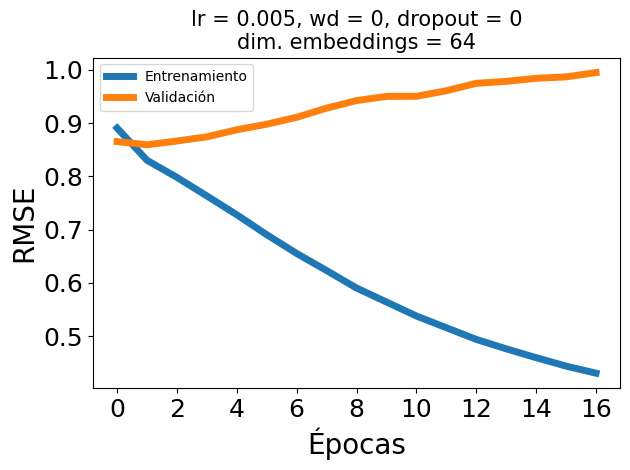

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.025 | Val Loss: 0.030
Epoch 10 |Train Loss: 0.020 | Val Loss: 0.033
Epoch 15 |Train Loss: 0.017 | Val Loss: 0.034
Early stopping en la época: 18


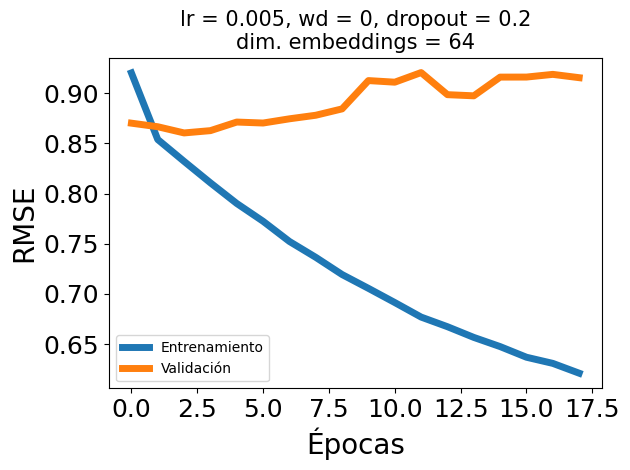

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.027 | Val Loss: 0.030
Epoch 10 |Train Loss: 0.024 | Val Loss: 0.031
Epoch 15 |Train Loss: 0.021 | Val Loss: 0.032
Early stopping en la época: 18


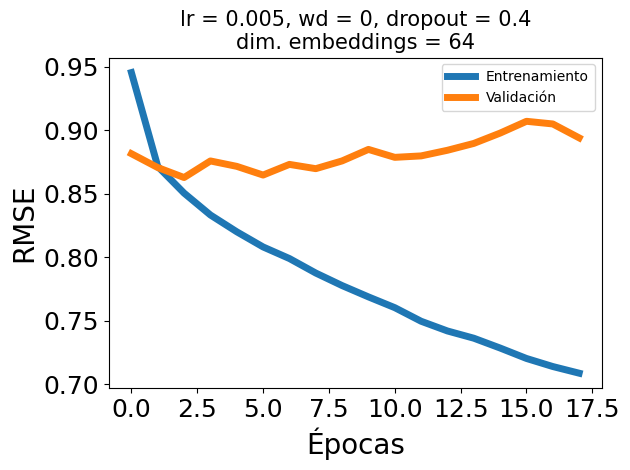

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.038 | Val Loss: 0.039
Epoch 10 |Train Loss: 0.038 | Val Loss: 0.039
Epoch 15 |Train Loss: 0.038 | Val Loss: 0.039
Epoch 20 |Train Loss: 0.038 | Val Loss: 0.039
Early stopping en la época: 23


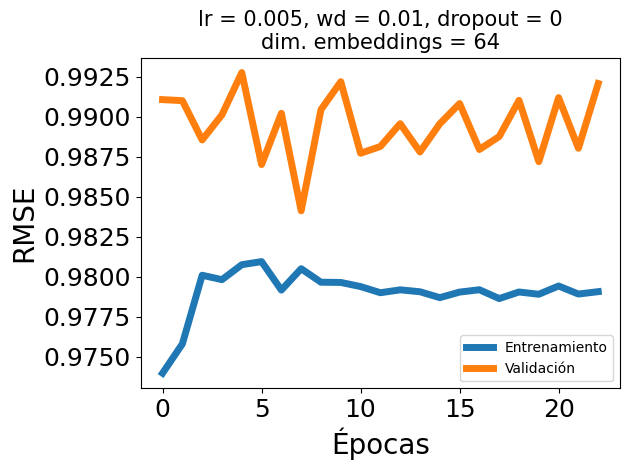

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.039 | Val Loss: 0.041
Epoch 10 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 15 |Train Loss: 0.039 | Val Loss: 0.039
Early stopping en la época: 19


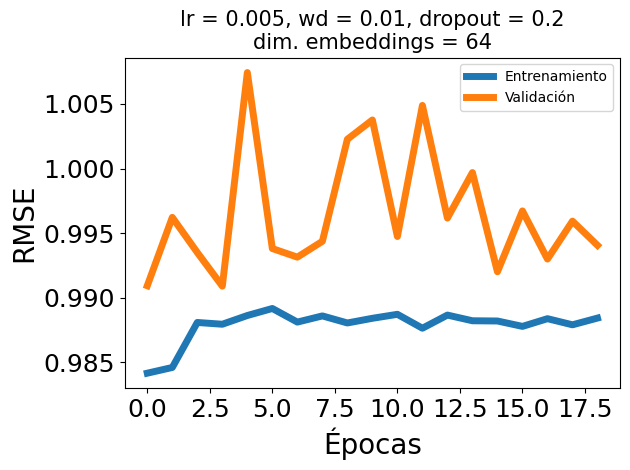

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.040 | Val Loss: 0.040
Epoch 10 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 15 |Train Loss: 0.040 | Val Loss: 0.040
Epoch 20 |Train Loss: 0.040 | Val Loss: 0.040
Early stopping en la época: 22


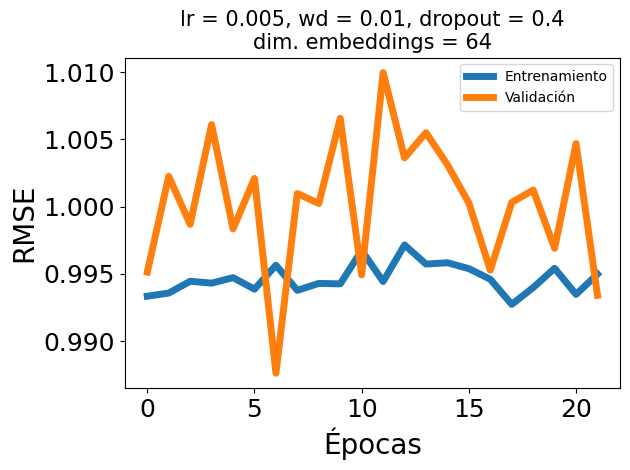

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.026 | Val Loss: 0.028
Epoch 10 |Train Loss: 0.022 | Val Loss: 0.028
Epoch 15 |Train Loss: 0.020 | Val Loss: 0.029
Epoch 20 |Train Loss: 0.019 | Val Loss: 0.030
Early stopping en la época: 24


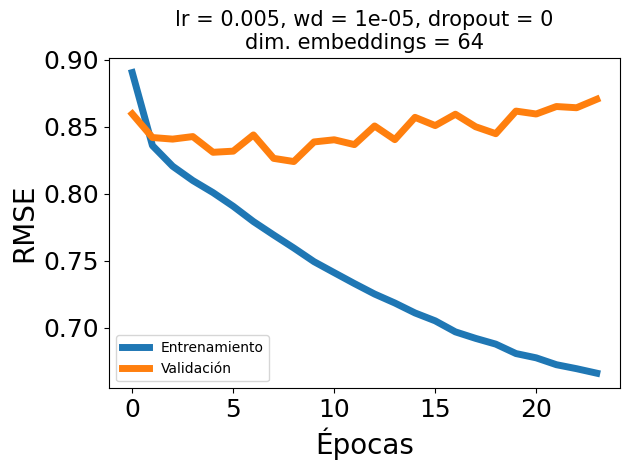

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.027 | Val Loss: 0.029
Epoch 10 |Train Loss: 0.025 | Val Loss: 0.028
Epoch 15 |Train Loss: 0.024 | Val Loss: 0.028
Epoch 20 |Train Loss: 0.023 | Val Loss: 0.029
Epoch 25 |Train Loss: 0.022 | Val Loss: 0.029
Early stopping en la época: 25


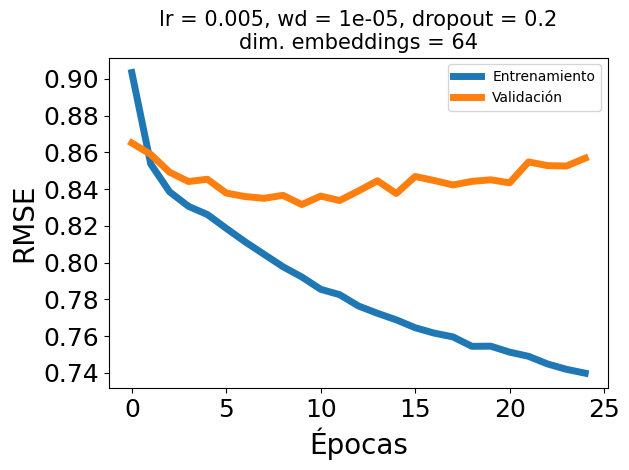

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.028 | Val Loss: 0.028
Epoch 10 |Train Loss: 0.027 | Val Loss: 0.029
Epoch 15 |Train Loss: 0.026 | Val Loss: 0.029
Epoch 20 |Train Loss: 0.025 | Val Loss: 0.028
Epoch 25 |Train Loss: 0.025 | Val Loss: 0.029
Epoch 30 |Train Loss: 0.025 | Val Loss: 0.030
Early stopping en la época: 31


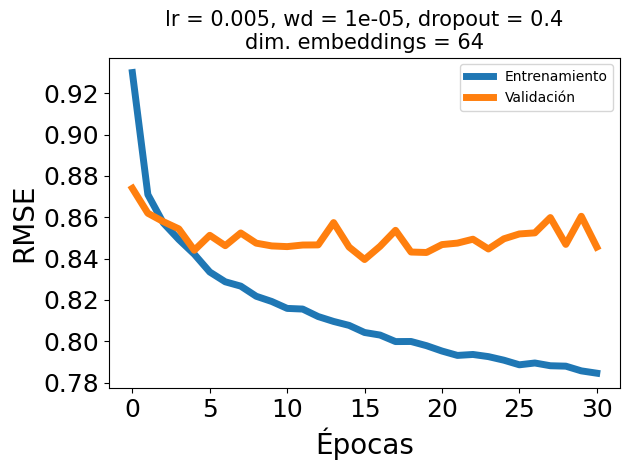

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.020 | Val Loss: 0.032
Epoch 10 |Train Loss: 0.011 | Val Loss: 0.036
Epoch 15 |Train Loss: 0.008 | Val Loss: 0.038
Early stopping en la época: 17


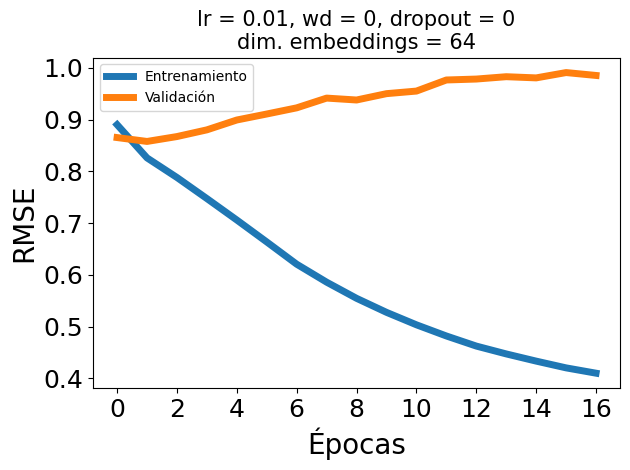

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.025 | Val Loss: 0.030
Epoch 10 |Train Loss: 0.019 | Val Loss: 0.033
Epoch 15 |Train Loss: 0.016 | Val Loss: 0.035
Early stopping en la época: 18


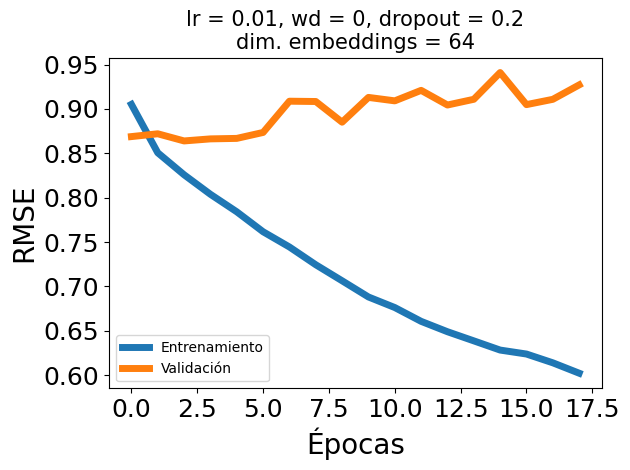

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.028 | Val Loss: 0.031
Epoch 10 |Train Loss: 0.026 | Val Loss: 0.031
Epoch 15 |Train Loss: 0.024 | Val Loss: 0.032
Epoch 20 |Train Loss: 0.022 | Val Loss: 0.034
Early stopping en la época: 21


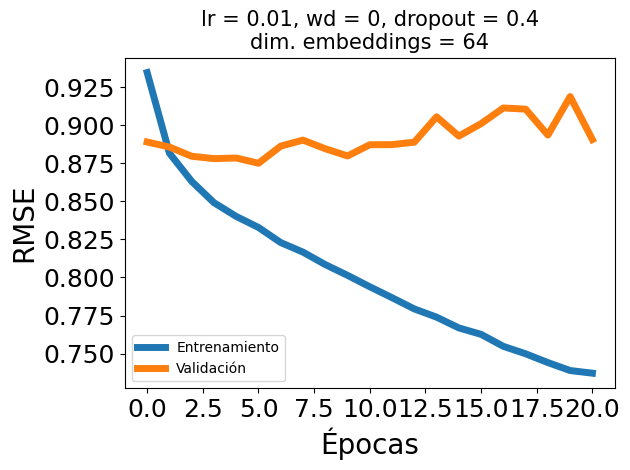

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.038 | Val Loss: 0.040
Epoch 10 |Train Loss: 0.038 | Val Loss: 0.039
Epoch 15 |Train Loss: 0.038 | Val Loss: 0.039
Early stopping en la época: 19


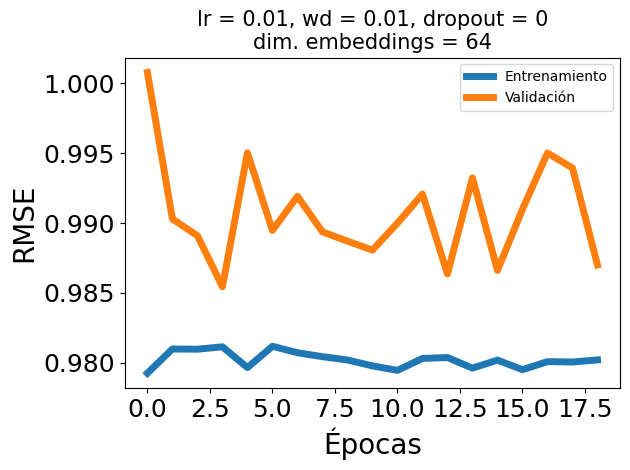

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.040 | Val Loss: 0.040
Epoch 10 |Train Loss: 0.040 | Val Loss: 0.040
Epoch 15 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 20 |Train Loss: 0.039 | Val Loss: 0.040
Early stopping en la época: 21


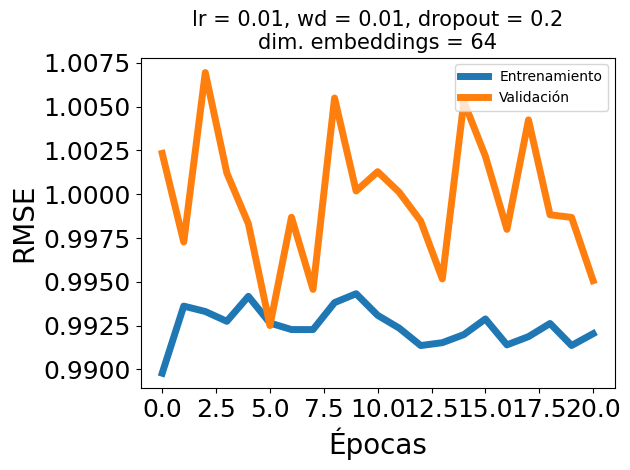

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.040 | Val Loss: 0.040
Epoch 10 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 15 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 20 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 25 |Train Loss: 0.040 | Val Loss: 0.040
Early stopping en la época: 29


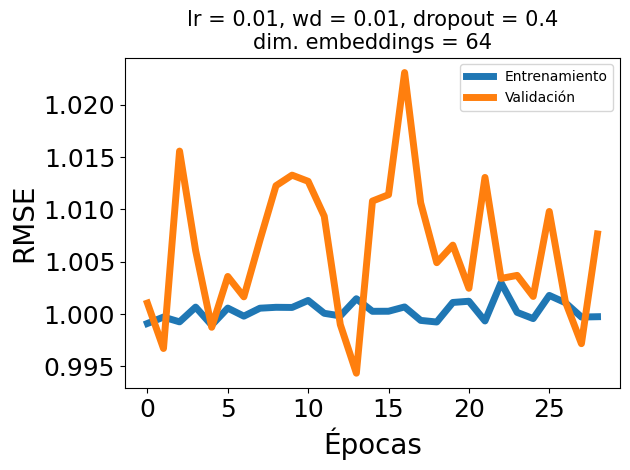

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.027 | Val Loss: 0.028
Epoch 10 |Train Loss: 0.025 | Val Loss: 0.028
Epoch 15 |Train Loss: 0.025 | Val Loss: 0.028
Epoch 20 |Train Loss: 0.024 | Val Loss: 0.027
Epoch 25 |Train Loss: 0.024 | Val Loss: 0.028
Epoch 30 |Train Loss: 0.023 | Val Loss: 0.029
Epoch 35 |Train Loss: 0.023 | Val Loss: 0.028
Early stopping en la época: 35


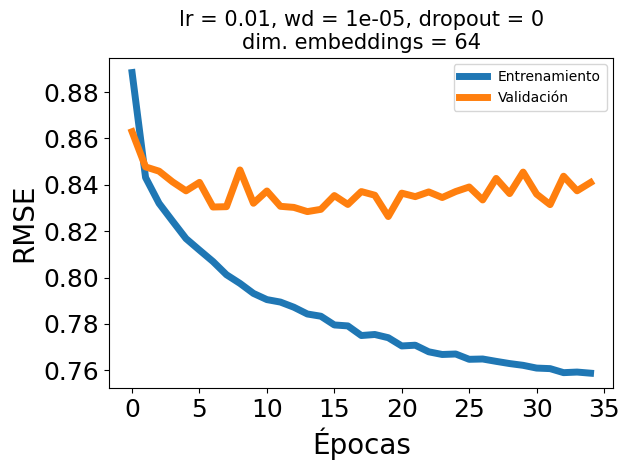

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.028 | Val Loss: 0.029
Epoch 10 |Train Loss: 0.027 | Val Loss: 0.028
Epoch 15 |Train Loss: 0.027 | Val Loss: 0.028
Epoch 20 |Train Loss: 0.026 | Val Loss: 0.028
Epoch 25 |Train Loss: 0.026 | Val Loss: 0.028
Epoch 30 |Train Loss: 0.026 | Val Loss: 0.029
Early stopping en la época: 30


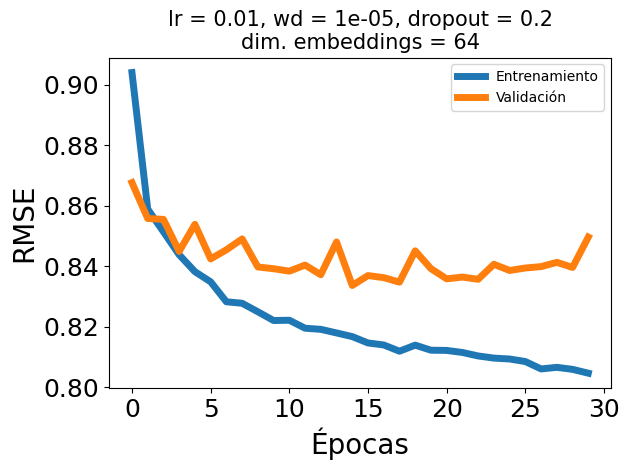

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.029 | Val Loss: 0.030
Epoch 10 |Train Loss: 0.028 | Val Loss: 0.029
Epoch 15 |Train Loss: 0.028 | Val Loss: 0.029
Epoch 20 |Train Loss: 0.028 | Val Loss: 0.029
Epoch 25 |Train Loss: 0.028 | Val Loss: 0.030
Epoch 30 |Train Loss: 0.028 | Val Loss: 0.029
Epoch 35 |Train Loss: 0.028 | Val Loss: 0.029
Epoch 40 |Train Loss: 0.027 | Val Loss: 0.030
Epoch 45 |Train Loss: 0.028 | Val Loss: 0.028
Epoch 50 |Train Loss: 0.028 | Val Loss: 0.028
Epoch 55 |Train Loss: 0.028 | Val Loss: 0.029
Epoch 60 |Train Loss: 0.027 | Val Loss: 0.029
Early stopping en la época: 60


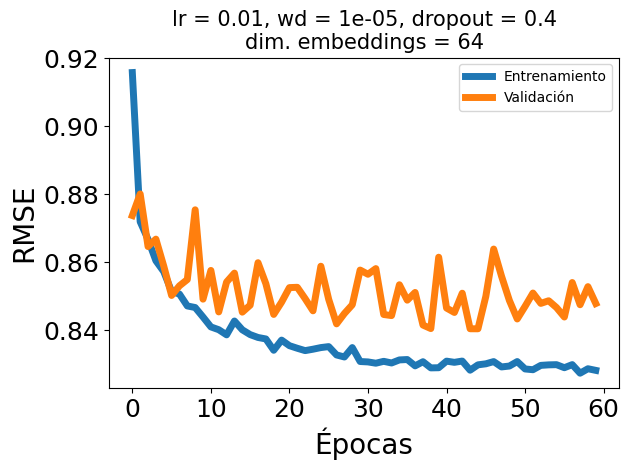

In [33]:
resultados_train =[] 
n=0
for tam_embedd in [32,64]:
    for lr in [1e-3,5e-3,1e-2]:
        for wd in [0,1e-2, 1e-5]:
            for drop in [0,0.2,0.4]:
                best_model,best_val, train_graf,val_graf, epoca_parada = entrenaRed(lr=lr,wd=wd, dropout=drop, epoca = 100, early_stop= 15,tam_embedd =tam_embedd)
                
                graf = graficaEntrenamiento(train_graf,val_graf,lr,wd,drop,n,tam_embedd)
                param_train = {
                    "lr":      lr,
                    "wd":      wd,
                    "dropout": drop,
                    "epoca_parada": epoca_parada ,
                    'tam_embeddings':tam_embedd,
                    "best_RMSE_val":best_val,
                    "grafica" : graf
                }
                resultados_train.append(param_train)
                n+=1

Se recopilan los resultados de todas las combinaciones en una tabla, se añade el RMSE en la escala original del rating, y se guarda en un csv.

In [34]:
tabla_resultados = pd.DataFrame(resultados_train)
tabla_resultados.sort_values(['best_RMSE_val'])
tabla_resultados['RMSE_original']= (tabla_resultados['best_RMSE_val']**0.5)*5

tabla_resultados.to_csv("resultadosRNhybrid.csv", index=False)

Se ordenan las combinaciones de mejor a peor RMSE de validación. La mejor combinación usa dimensión de embedding 64, lr=0.005, wd=0.00001, dropout=0, con RMSE ≈ 0.824.

In [35]:
tabla_resultados.sort_values(['best_RMSE_val'])

,lr,wd,dropout,epoca_parada,tam_embeddings,best_RMSE_val,grafica,RMSE_original
42,0.005,0.00001,0.0,24,64,0.027163,42.png,0.824057
51,0.010,0.00001,0.0,35,64,0.027311,51.png,0.826306
24,0.010,0.00001,0.0,22,32,0.027526,24.png,0.829555
15,0.005,0.00001,0.0,21,32,0.027561,15.png,0.830071
43,0.005,0.00001,0.2,25,64,0.027662,43.png,0.831597
16,0.005,0.00001,0.2,21,32,0.027667,16.png,0.831672
34,0.001,0.00001,0.2,24,64,0.027701,34.png,0.832183
52,0.010,0.00001,0.2,30,64,0.027801,52.png,0.833675
25,0.010,0.00001,0.2,35,32,0.027868,25.png,0.834687
35,0.001,0.00001,0.4,26,64,0.027951,35.png,0.835924


## Reentrenamiento final y evaluación
Con la mejor configuración de hiperparámetros, entrenaRedCompleta reentrena el modelo desde cero usando train+val (dataloader_train_val), esta vez sin conjunto de validación ni early stopping, durante un número fijo de épocas.

In [46]:
def  entrenaRedCompleta(lr,wd,dropout,epoca,embedDim):
    criterion = nn.MSELoss()
    model =NCF(numUsers,numItems,numVar,dropout,embedDim) 
    optimizer =optim.Adam(model.parameters(), lr=lr,weight_decay=wd)
    
    for epoch in range(epoca):
        model.train()
        train_loss = 0
        for user, item, X,y in dataloader_train_val:
            optimizer.zero_grad()
            pred= model(user, item,X)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(dataloader_train_val)
        
        if (epoch + 1) %5 ==0:
            print(f"Epoch {epoch+1} |Train Loss: {train_loss:.3f} ")
            
        
    return  model

Recordatorio de la mejor configuración encontrada en el grid search (fila 42 de la tabla): lr=0.005, wd=0.00001, dropout=0, época de parada 24, dimensión de embedding 64, RMSE ≈ 0.824.

In [ ]:
#  mejor modelo entrenamiento: 42	0.005	0.00001	0.0	24	64	0.027163	42.png	0.824057

In [49]:
def evaluacion (lr,wd,dropout,epoca,embedDim):
    final_model = entrenaRedCompleta(lr,wd,dropout,epoca,embedDim)
    
    criterion = nn.MSELoss()
    final_model.eval()
    test_loss = 0
    test_mae = 0
    with torch.no_grad():
        for user, item, X,y in dataloader_test:
            pred = final_model(user,item,X)
            loss = criterion(pred, y)
            test_loss += loss.item()
            test_mae += torch.abs(pred - y).mean().item()
    mse = test_loss / len(dataloader_test)
    rmse = (mse ** 0.5) * 5.0
    mae = (test_mae / len(dataloader_test)) * 5.0
    print("Test RMSE:", rmse)
    print("Test MAE:", mae)

    return final_model, rmse

evaluacion llama a entrenaRedCompleta y, una vez entrenado el modelo final, calcula el RMSE y el MAE sobre el conjunto de test (deshaciendo la normalización, multiplicando por 5). La siguiente celda es una comprobación rápida de la diferencia aproximada de RMSE entre el modelo puramente colaborativo (≈0.89, ver RNcolADAM.ipynb) y este modelo híbrido.

In [64]:
0.89-0.87

0.020000000000000018

Se reentrena y evalúa con la mejor configuración encontrada (lr=0.005, wd=0.00001, dropout=0, embedDim=64, 24 épocas).

In [48]:
evaluacion(lr=0.005, wd=0.00001,dropout=0, epoca=24, embedDim=64)

Epoch 5 |Train Loss: 0.026 
Epoch 10 |Train Loss: 0.023 
Epoch 15 |Train Loss: 0.022 
Epoch 20 |Train Loss: 0.021 
Test RMSE: 0.8468080290392286
Test MAE: 0.6364501895088899


(NCF(
   (user_embedding): Embedding(610, 64)
   (item_embedding): Embedding(9598, 64)
   (fc1): Linear(in_features=153, out_features=64, bias=True)
   (fc2): Linear(in_features=64, out_features=32, bias=True)
   (fc3): Linear(in_features=32, out_features=1, bias=True)
   (relu): ReLU()
   (dropout): Dropout(p=0, inplace=False)
   (sigmoid): Sigmoid()
 ),
 0.8468080290392286)

Se convierten a RMSE en la escala original los valores de train loss impresos en las épocas 5, 10, 15 y 20 del entrenamiento anterior, para ver su evolución.

In [50]:
#perdida por epoca en entranamiento (val+train)
print(f" Época 5: {round(( 0.026 ** 0.5) * 5.0,3)}")
print(f" Época 10: {round(( 0.023 ** 0.5) * 5.0,3)}")
print(f" Época 15: {round(( 0.022 ** 0.5) * 5.0,3)}")
print(f" Época 20: {round(( 0.021 ** 0.5) * 5.0,3)}")

 Época 5: 0.806
 Época 10: 0.758
 Época 15: 0.742
 Época 20: 0.725


## Tabla de resultados para la memoria
Se recarga el csv con los resultados del grid search y se filtran los de dimensión de embedding 96 (que aquí ni siquiera se probó, por lo que el filtro no elimina nada), dejando las columnas de interés y el RMSE redondeado a 3 decimales.

In [51]:
resultados = pd.read_csv("resultadosRNhybrid.csv")
resultados_2 = resultados[resultados['tam_embeddings']!=96].sort_values('best_RMSE_val')
resultados_3 = resultados_2[["lr","wd","dropout","epoca_parada","tam_embeddings","RMSE_original"]]
resultados_3['RMSE_original']=round(resultados_3['RMSE_original'],3)

In [52]:
resultados_2

,lr,wd,dropout,epoca_parada,tam_embeddings,best_RMSE_val,grafica,RMSE_original
42,0.005,0.00001,0.0,24,64,0.027163,42.png,0.824057
51,0.010,0.00001,0.0,35,64,0.027311,51.png,0.826306
24,0.010,0.00001,0.0,22,32,0.027526,24.png,0.829555
15,0.005,0.00001,0.0,21,32,0.027561,15.png,0.830071
43,0.005,0.00001,0.2,25,64,0.027662,43.png,0.831597
16,0.005,0.00001,0.2,21,32,0.027667,16.png,0.831672
34,0.001,0.00001,0.2,24,64,0.027701,34.png,0.832183
52,0.010,0.00001,0.2,30,64,0.027801,52.png,0.833675
25,0.010,0.00001,0.2,35,32,0.027868,25.png,0.834687
35,0.001,0.00001,0.4,26,64,0.027951,35.png,0.835924


In [53]:
resultados_3

,lr,wd,dropout,epoca_parada,tam_embeddings,RMSE_original
42,0.005,0.00001,0.0,24,64,0.824
51,0.010,0.00001,0.0,35,64,0.826
24,0.010,0.00001,0.0,22,32,0.830
15,0.005,0.00001,0.0,21,32,0.830
43,0.005,0.00001,0.2,25,64,0.832
16,0.005,0.00001,0.2,21,32,0.832
34,0.001,0.00001,0.2,24,64,0.832
52,0.010,0.00001,0.2,30,64,0.834
25,0.010,0.00001,0.2,35,32,0.835
35,0.001,0.00001,0.4,26,64,0.836


Se exporta la tabla a formato LaTeX, para poder incluirla directamente en la memoria, y se guarda también en un archivo .tex.

In [62]:
latex = resultados_3.to_latex(
    index=False,
    caption="Resultados del entrenamiento",
    float_format=lambda x: f"{x:g}"
)

In [63]:
print(latex)
with open("tabla.tex", "w", encoding="utf-8") as f:
    f.write(latex)

\begin{table}
\caption{Resultados del entrenamiento}
\begin{tabular}{rrrrrr}
\toprule
lr & wd & dropout & epoca_parada & tam_embeddings & RMSE_original \\
\midrule
0.005 & 1e-05 & 0 & 24 & 64 & 0.824 \\
0.01 & 1e-05 & 0 & 35 & 64 & 0.826 \\
0.01 & 1e-05 & 0 & 22 & 32 & 0.83 \\
0.005 & 1e-05 & 0 & 21 & 32 & 0.83 \\
0.005 & 1e-05 & 0.2 & 25 & 64 & 0.832 \\
0.005 & 1e-05 & 0.2 & 21 & 32 & 0.832 \\
0.001 & 1e-05 & 0.2 & 24 & 64 & 0.832 \\
0.01 & 1e-05 & 0.2 & 30 & 64 & 0.834 \\
0.01 & 1e-05 & 0.2 & 35 & 32 & 0.835 \\
0.001 & 1e-05 & 0.4 & 26 & 64 & 0.836 \\
0.005 & 1e-05 & 0.4 & 24 & 32 & 0.837 \\
0.001 & 1e-05 & 0.4 & 27 & 32 & 0.838 \\
0.001 & 1e-05 & 0.2 & 26 & 32 & 0.839 \\
0.005 & 1e-05 & 0.4 & 31 & 64 & 0.84 \\
0.01 & 1e-05 & 0.4 & 60 & 64 & 0.84 \\
0.01 & 1e-05 & 0.4 & 38 & 32 & 0.841 \\
0.001 & 1e-05 & 0 & 24 & 32 & 0.843 \\
0.001 & 1e-05 & 0 & 22 & 64 & 0.843 \\
0.001 & 0 & 0.4 & 25 & 32 & 0.854 \\
0.001 & 0 & 0.2 & 24 & 32 & 0.856 \\
0.001 & 0 & 0.4 & 24 & 64 & 0.857 \\
0.005 & 0

## Interpretabilidad con SHAP
Se vuelve a entrenar y evaluar el modelo con la mejor configuración, para quedarse con el modelo entrenado y analizar qué peso tiene cada entrada en sus predicciones mediante SHAP.

Como SHAP necesita una red que reciba directamente el vector de entrada (y no por separado usuario, película y variables), se construye Z: la concatenación del embedding de usuario, el embedding de película y las variables de contenido, para una muestra de fondo (idx_bg, usada como referencia) y una muestra a explicar (idx_exp).

In [57]:
import shap
import numpy as np
model, rmse = evaluacion(lr=0.005, wd=0.00001, dropout=0, epoca=24, embedDim=64)

model.eval()   # importante: apaga dropout

Xall      = dataset_test.X         # [N,24] ya normalizado
users_all = dataset_test.userInd   # [N]
items_all = dataset_test.movieInd  # [N]

# muestras (GradientExplainer es rápido, pero no hace falta el set entero)
idx_bg  = torch.randperm(len(Xall))[:100]   # fondo / baseline
idx_exp = torch.randperm(len(Xall))[:500]   # instancias a explicar

def construye_Z(u, it, X):
    with torch.no_grad():
        ue = model.user_embedding(u)
        ie = model.item_embedding(it)
    return torch.cat([ue, ie, X], dim=1).float()

Z_bg  = construye_Z(users_all[idx_bg],  items_all[idx_bg],  Xall[idx_bg])
Z_exp = construye_Z(users_all[idx_exp], items_all[idx_exp], Xall[idx_exp])

Epoch 5 |Train Loss: 0.025 
Epoch 10 |Train Loss: 0.023 
Epoch 15 |Train Loss: 0.022 
Epoch 20 |Train Loss: 0.021 
Test RMSE: 0.8437465473532213
Test MAE: 0.634814964509324


NCFHead envuelve solo la parte final del modelo (las capas totalmente conectadas), que es la que recibe directamente Z como entrada, sin las capas de embedding. Sobre esa cabeza se aplica GradientExplainer de SHAP, usando Z_bg como fondo, para calcular los valores SHAP de las instancias de Z_exp.

In [59]:
class NCFHead(nn.Module):
    def __init__(self, ncf):
        super().__init__()
        self.fc1, self.fc2, self.fc3 = ncf.fc1, ncf.fc2, ncf.fc3
        self.relu, self.sigmoid = ncf.relu, ncf.sigmoid
    def forward(self, z):
        x = self.relu(self.fc1(z))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x          # <-- antes: x.squeeze(-1)  -> deja [batch, 1]

head = NCFHead(model).eval()

explainer = shap.GradientExplainer(head, Z_bg)
shap_vals = explainer.shap_values(Z_exp)

Se calcula la importancia media de cada columna de Z (valor absoluto de su SHAP), y se suman por bloques: embedding de usuario, embedding de película y variables de contenido. Así se ve qué parte de la predicción viene de la información colaborativa (usuario/película) y qué parte de las variables de contenido. El summary_plot muestra el detalle solo de las variables de contenido, para ver cuáles pesan más (por ejemplo, si vote_average domina sobre el resto).

(500, 153)
Aporte colaborativo (user): 0.16208099046567956
Aporte colaborativo (item): 0.06232433994859775
Aporte contenido (metadata): 0.19870069581504557


C:\Users\lucia\AppData\Local\Temp\ipykernel_18976\2141026786.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv[:, 2*embedDim:],


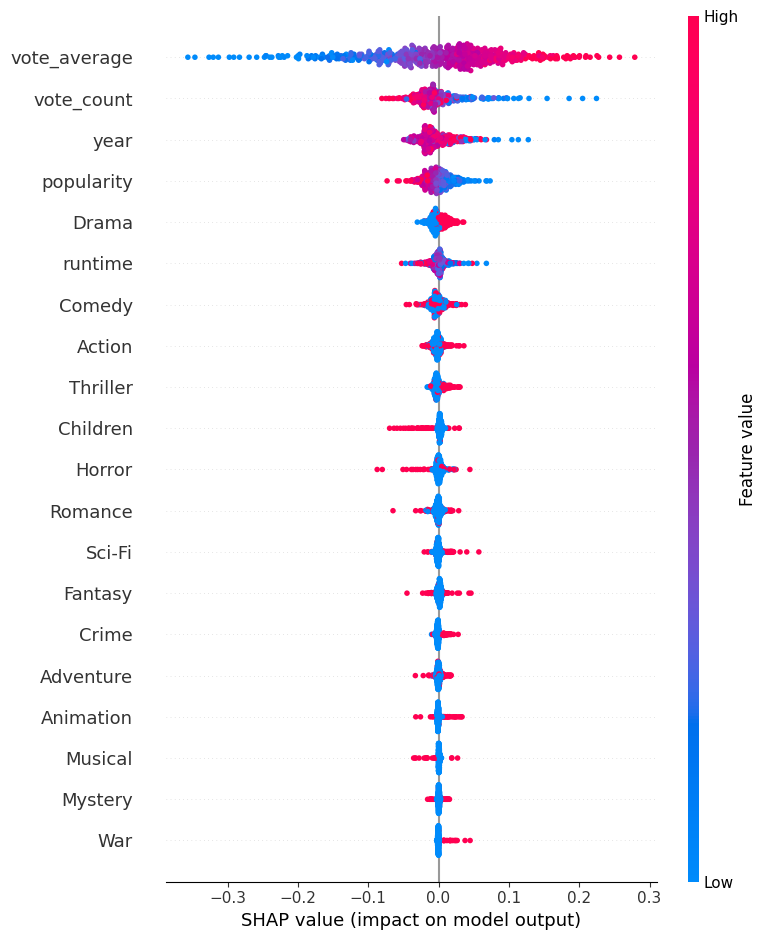

In [61]:
embedDim = model.user_embedding.embedding_dim   # 64
nombres = ([f"user_emb_{i}" for i in range(embedDim)] +
           [f"item_emb_{i}" for i in range(embedDim)] +
           list(variables))
shap_vals = explainer.shap_values(Z_exp)

sv = np.array(shap_vals)
if sv.ndim == 3:        # a veces vuelve [M, 152, 1]
    sv = sv[..., 0]

print(sv.shape)         # debería ser [M, 152]
imp = np.abs(sv).mean(0)   # importancia media |SHAP| por columna

print("Aporte colaborativo (user):", imp[:embedDim].sum())
print("Aporte colaborativo (item):", imp[embedDim:2*embedDim].sum())
print("Aporte contenido (metadata):", imp[2*embedDim:].sum())

# summary plot SOLO de las 24 variables de contenido -> aquí ves si vote_average domina
shap.summary_plot(sv[:, 2*embedDim:],
                  Z_exp[:, 2*embedDim:].numpy(),
                  feature_names=list(variables))

## Análisis del error según la popularidad de la película
Se generan las predicciones del modelo sobre todo el conjunto de test. Después, para cada película se cuenta cuántas veces aparece en train (su popularidad), se agrupan las películas en tramos de popularidad (sin valoraciones en train, 1-5, 6-10, 11-20, 21-50, 51-100 y más de 100), y se calcula el RMSE del modelo dentro de cada tramo. Esto permite ver si el modelo predice mejor las películas populares que las que tienen pocas valoraciones. La tabla también se exporta a LaTeX.

In [82]:
# predicciones del mdelo hibrido sobre test(sin batch)
model.eval()
with torch.no_grad():
    user  = torch.tensor(test['userIndice'].values,  dtype=torch.long)
    item = torch.tensor(test['movieIndice'].values, dtype=torch.long)
    X = torch.from_numpy(test[variables].values.astype(np.float32))
    pred_hibrido = model(user, item, X).numpy() * 5.0     

# cuantos ratings tiene cada peli en TRAIN -> embedding de pelicula más representativo cuantas más veces
frecuencia = train.groupby('movieId').size()
test['frecuencia'] = test['movieId'].map(frecuencia).fillna(0) #fillna para peliculas que no aparecen en train

#  tramos de frecuencia se corta la variable (los intervalos son cerrados por la derecha)
bins   = [-1, 0, 5, 10, 20, 50, 100, np.inf]
labels = ['0 ', '1-5', '6-10', '11-20','21-50' ,'51-100' ,'+100']
test['grupos'] = pd.cut(test['frecuencia'], bins=bins, labels=labels)

# RMSE por tramo
def rmse_por_grupo(y_pred):
    err2 = (y_pred - test['rating'].values) ** 2
    resultados = pd.DataFrame({'grupo': test['grupos'].values, 'err2': err2})
    return resultados.groupby('grupo').agg(n=('err2', 'size'), rmse=('err2', lambda e: round(e.mean() ** 0.5,3)))

sol = rmse_por_grupo(pred_hibrido)
print(sol)
latex = sol.to_latex(
    index=False,
    caption="Resultados del entrenamiento intervalos",
    float_format=lambda x: f"{x:g}"
)
print(latex)
with open("tabla.tex", "w", encoding="utf-8") as f:
    f.write(latex)

           n   rmse
grupo              
0       1471  0.842
1-5     3153  0.842
6-10    1727  0.841
11-20   2045  0.816
21-50   3871  0.862
51-100  1801  0.863
+100     992  0.821
\begin{table}
\caption{Resultados del entrenamiento intervalos}
\begin{tabular}{rr}
\toprule
n & rmse \\
\midrule
1471 & 0.842 \\
3153 & 0.842 \\
1727 & 0.841 \\
2045 & 0.816 \\
3871 & 0.862 \\
1801 & 0.863 \\
992 & 0.821 \\
\bottomrule
\end{tabular}
\end{table}



Se extrae el RMSE de cada tramo de popularidad como array, para poder compararlo con el de otros modelos (por ejemplo, con el del modelo puramente colaborativo en RNcolADAM.ipynb).

In [88]:
sol['rmse'].to_numpy()

array([0.842, 0.842, 0.841, 0.816, 0.862, 0.863, 0.821])